# Seasonal Agriculture Performance Analysis

## Major Project – VOIS AICTE Batch 1 2026–2027

This project analyzes agricultural performance across different seasons using
environmental, farming, production, resource-use and economic variables.

The analysis focuses on:
- Seasonal agricultural performance
- Environmental conditions
- Resource utilization
- Crop and irrigation performance
- Production and profitability
- Relationships among important variables
- Evidence-based insights and recommendations

## 1. Problem Statement

Agricultural activities are influenced by seasonal variations in environmental
conditions, farming practices, resource availability and market conditions.
Therefore, agricultural performance can vary from one season to another.

The objective of this project is to analyze the given agricultural dataset and
identify meaningful seasonal patterns, trends, relationships and variations in
agricultural performance.

The analysis aims to compare seasons, identify important differences, examine
resource usage and economic outcomes, investigate relationships between
environmental conditions and agricultural performance, and develop
evidence-based recommendations.

## 2. Project Objectives

1. Understand the structure and quality of the agricultural dataset.
2. Clean and prepare the dataset for analysis.
3. Explore agricultural performance across seasons.
4. Analyze environmental and farming conditions.
5. Compare crop performance across seasons.
6. Compare irrigation methods and resource usage.
7. Analyze production, revenue, cost and profit.
8. Investigate relationships between important variables.
9. Identify unusual patterns and potential outliers.
10. Develop evidence-based insights and recommendations.

In [4]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

%matplotlib inline

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Visualization style
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [5]:
# Load the dataset

file_path = "seasonal_agriculture_performance_dataset.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [6]:
# Basic information about the dataset

print("Dataset Shape:", df.shape)
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Dataset Shape: (4000, 28)
Number of Rows: 4000
Number of Columns: 28


In [7]:
# Display first five records

df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [8]:
# Display first five records

df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [9]:
# Display last five records

df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,7.97,27.30,104.30,44.80,94.00,Drip,271.10,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,6.57,33.70,127.80,44.90,91.30,Drip,176.60,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,7.25,21.10,126.70,59.90,148.00,Drip,234.70,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,6.11,30.50,107.50,20.70,91.00,Sprinkler,329.70,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,6.16,35.70,137.10,92.60,145.50,Sprinkler,205.90,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30


In [10]:
# Display five random records

df.sample(5, random_state=42)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
555,SF10556,Andhra Pradesh,Nashik,Chilli,Rabi,7.94,456.80,25.30,47.70,7.60,7.10,12.90,108.00,75.80,96.50,Flood,228.20,8.51,0.87,NaN,15.64,92892,619157,1452831,833674,6146,2.54,34.40
3491,SF13492,Punjab,Warangal,Wheat,Kharif,12.44,601.90,27.20,60.20,8.30,7.66,24.30,97.80,36.70,96.00,Drip,65.90,6.88,0.77,0.94,11.69,23614,680562,276048,-404514,5818,2.01,31.80
527,SF10528,Maharashtra,Indore,Cotton,Kharif,6.35,"1,213.70",26.30,73.60,7.10,6.33,30.40,149.30,41.80,98.80,Drip,143.00,5.63,0.69,1.17,7.43,69828,441813,518822,77009,4491,1.65,52.70
3925,SF13926,Madhya Pradesh,Nashik,Wheat,Rabi,12.52,374.00,17.90,59.70,9.40,7.57,24.50,118.60,77.50,128.70,Rainfed,116.40,5.14,0.71,0.88,11.02,26649,744970,293672,-451298,3347,3.29,29.80
2989,SF12990,Gujarat,Rajkot,Chilli,Rabi,13.98,197.80,19.00,55.80,9.20,7.31,18.90,45.80,79.90,126.70,Flood,242.80,4.87,0.95,1.07,14.96,108549,994707,1623893,629186,10975,1.36,39.60


In [11]:
# Display all column names

print("Column Names:\n")

for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

Column Names:

1. Farm_ID
2. State
3. District
4. Crop
5. Season
6. Farm_Area_Hectares
7. Rainfall_mm
8. Avg_Temperature_C
9. Humidity_pct
10. Sunlight_Hours_Day
11. Soil_pH
12. Soil_Moisture_pct
13. Nitrogen_kg_ha
14. Phosphorus_kg_ha
15. Potassium_kg_ha
16. Irrigation_Method
17. Fertilizer_kg_ha
18. Pesticide_Litre_ha
19. Seed_Quality_Score
20. Yield_Tonnes_Ha
21. Production_Tonnes
22. Market_Price_INR_Tonne
23. Total_Cost_INR
24. Revenue_INR
25. Profit_INR
26. Water_Used_m3
27. Water_Efficiency_t_per_1000m3
28. Disease_Pest_Risk_pct


In [12]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [13]:
# Display data types

data_types = pd.DataFrame({
    "Column": df.columns,
    "Data_Type": df.dtypes.astype(str).values
})

data_types

,Column,Data_Type
0,Farm_ID,object
1,State,object
2,District,object
3,Crop,object
4,Season,object
5,Farm_Area_Hectares,float64
6,Rainfall_mm,float64
7,Avg_Temperature_C,float64
8,Humidity_pct,float64
9,Sunlight_Hours_Day,float64


In [14]:
# Descriptive statistics for numerical variables

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,"3,952.00",601.15,288.93,80.00,370.20,582.00,834.95,"1,395.20"
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40
Soil_Moisture_pct,"3,960.00",26.51,6.71,8.00,21.70,26.40,31.30,47.00
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00


In [15]:
# Descriptive statistics for categorical variables

df.describe(include="object").T

,count,unique,top,freq
Farm_ID,4000,4000,SF10001,1
State,4000,8,Andhra Pradesh,529
District,4000,10,Ludhiana,427
Crop,4000,8,Rice,690
Season,4000,3,Kharif,1779
Irrigation_Method,4000,4,Flood,1310


In [16]:
# Identify column types

numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("Numerical Columns:")
print(numeric_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Categorical Columns:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


## 3. Variable Classification

### Identifier Variables
- Farm_ID

### Categorical Variables
- State
- District
- Crop
- Season
- Irrigation_Method

### Environmental Variables
- Rainfall_mm
- Avg_Temperature_C
- Humidity_pct
- Sunlight_Hours_Day
- Soil_pH
- Soil_Moisture_pct
- Disease_Pest_Risk_pct

### Resource / Operational Variables
- Nitrogen_kg_ha
- Phosphorus_kg_ha
- Potassium_kg_ha
- Fertilizer_kg_ha
- Pesticide_Litre_ha
- Seed_Quality_Score
- Water_Used_m3
- Irrigation_Method

### Production / Performance Variables
- Yield_Tonnes_Ha
- Production_Tonnes
- Water_Efficiency_t_per_1000m3

### Economic Variables
- Market_Price_INR_Tonne
- Total_Cost_INR
- Revenue_INR
- Profit_INR

The most important variables for seasonal agricultural performance are
Season, Crop, Yield, Production, Profit, Revenue, Cost, rainfall,
temperature, soil moisture, irrigation, water use and disease/pest risk.

In [18]:
# Check missing values

missing_count = df.isnull().sum()
missing_percentage = (df.isnull().mean() * 100)

missing_summary = pd.DataFrame({
    "Missing_Count": missing_count,
    "Missing_Percentage": missing_percentage.round(2)
}).sort_values("Missing_Count", ascending=False)

missing_summary

,Missing_Count,Missing_Percentage
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80
Farm_ID,0,0.00
Irrigation_Method,0,0.00
Water_Efficiency_t_per_1000m3,0,0.00
Water_Used_m3,0,0.00
Profit_INR,0,0.00
Revenue_INR,0,0.00
Total_Cost_INR,0,0.00


In [19]:
# Display only columns containing missing values

missing_summary[missing_summary["Missing_Count"] > 0]

,Missing_Count,Missing_Percentage
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


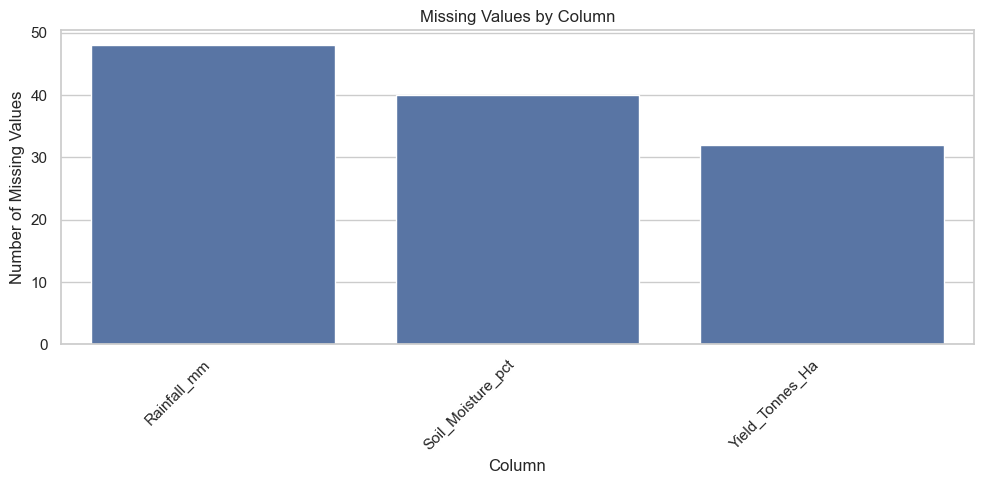

In [20]:
# Visualize missing values

missing_plot = missing_count[missing_count > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=missing_plot.index,
    y=missing_plot.values
)

plt.title("Missing Values by Column")
plt.xlabel("Column")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [21]:
# Check duplicate records

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [22]:
# Remove duplicate rows if any exist

df = df.drop_duplicates().reset_index(drop=True)

print("Dataset shape after duplicate removal:", df.shape)

Dataset shape after duplicate removal: (4000, 28)


In [23]:
# Handle missing values in numerical columns using median imputation

numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

for col in numeric_columns:
    if df[col].isnull().sum() > 0:
        median_value = df[col].median()
        df[col] = df[col].fillna(median_value)

print("Total remaining missing values:", df.isnull().sum().sum())

Total remaining missing values: 0


In [24]:
# Verify missing values after cleaning

cleaning_check = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().mean() * 100).round(2)
})

cleaning_check[cleaning_check["Missing_Count"] > 0]

,Missing_Count,Missing_Percentage


In [25]:
# Examine unique values in categorical variables

for col in categorical_columns:
    print(f"\n{col}")
    print("-" * 50)
    print("Number of unique values:", df[col].nunique())
    print(df[col].unique())


Farm_ID
--------------------------------------------------
Number of unique values: 4000
['SF10001' 'SF10002' 'SF10003' ... 'SF13998' 'SF13999' 'SF14000']

State
--------------------------------------------------
Number of unique values: 8
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District
--------------------------------------------------
Number of unique values: 10
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop
--------------------------------------------------
Number of unique values: 8
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season
--------------------------------------------------
Number of unique values: 3
['Kharif' 'Rabi' 'Zaid']

Irrigation_Method
--------------------------------------------------
Number of unique values: 4
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [26]:
# Count records by season

season_counts = df["Season"].value_counts()

print(season_counts)

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


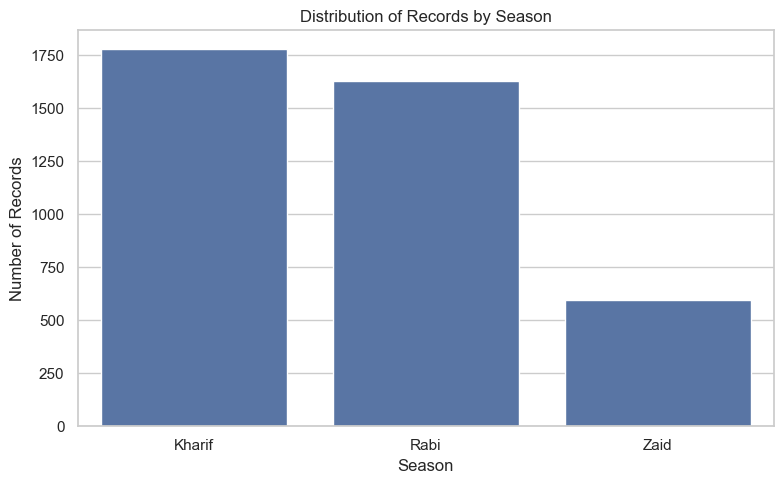

In [27]:
# Distribution of records by season

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Season",
    order=df["Season"].value_counts().index
)

plt.title("Distribution of Records by Season")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

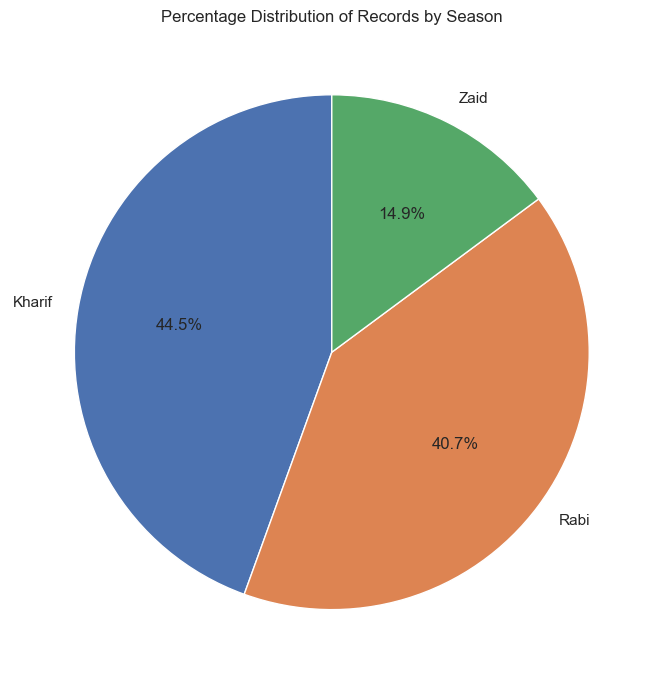

In [28]:
# Seasonal record percentage

season_percent = df["Season"].value_counts(normalize=True) * 100

plt.figure(figsize=(7, 7))

season_percent.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Percentage Distribution of Records by Season")
plt.ylabel("")
plt.tight_layout()
plt.show()

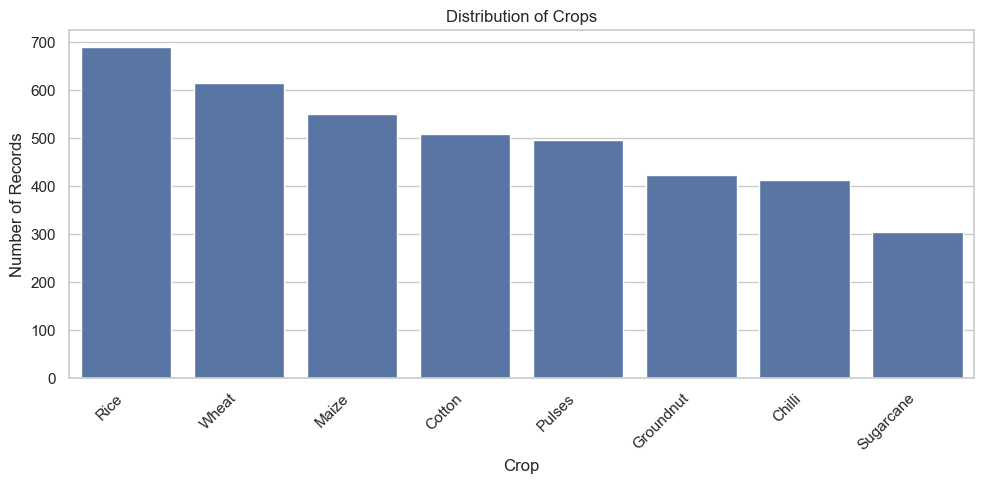

In [29]:
# Crop distribution

crop_counts = df["Crop"].value_counts()

plt.figure(figsize=(10, 5))

sns.barplot(
    x=crop_counts.index,
    y=crop_counts.values
)

plt.title("Distribution of Crops")
plt.xlabel("Crop")
plt.ylabel("Number of Records")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

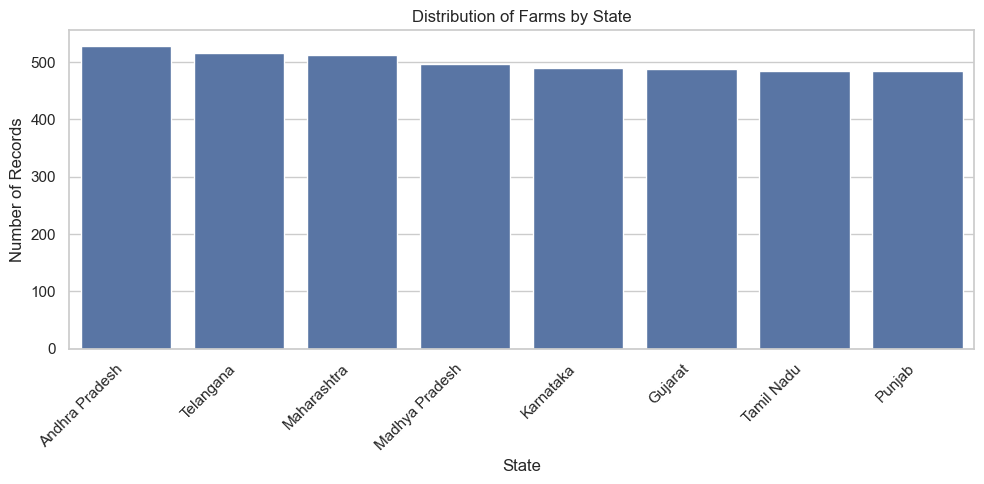

In [30]:
# Distribution of farms by state

state_counts = df["State"].value_counts()

plt.figure(figsize=(10, 5))

sns.barplot(
    x=state_counts.index,
    y=state_counts.values
)

plt.title("Distribution of Farms by State")
plt.xlabel("State")
plt.ylabel("Number of Records")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

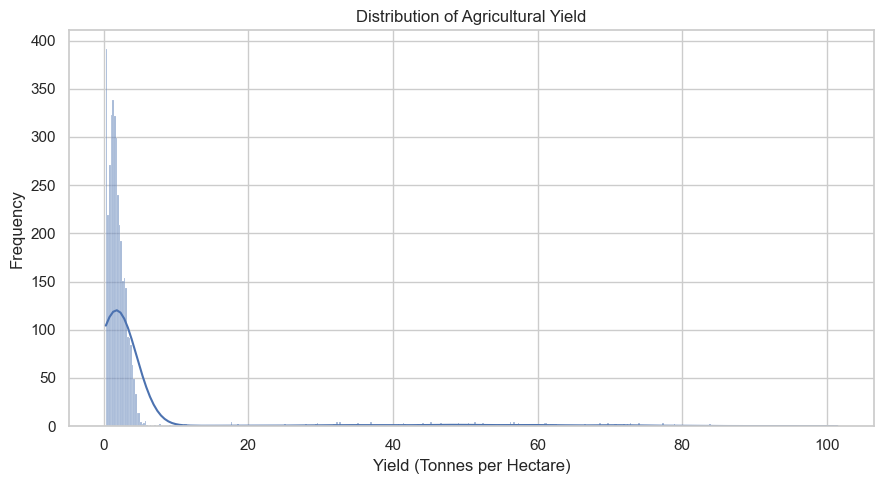

In [31]:
# Yield distribution

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Yield_Tonnes_Ha",
    kde=True
)

plt.title("Distribution of Agricultural Yield")
plt.xlabel("Yield (Tonnes per Hectare)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

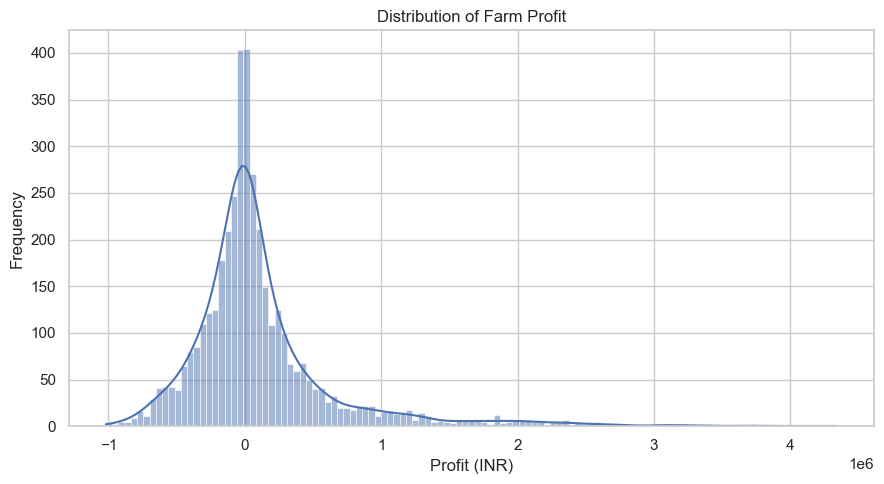

In [32]:
# Profit distribution

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Profit_INR",
    kde=True
)

plt.title("Distribution of Farm Profit")
plt.xlabel("Profit (INR)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

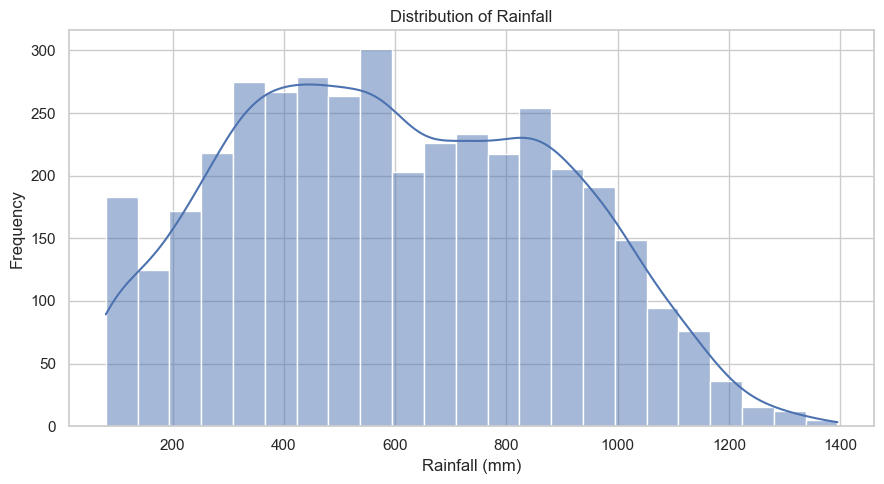

In [33]:
# Rainfall distribution

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Rainfall_mm",
    kde=True
)

plt.title("Distribution of Rainfall")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

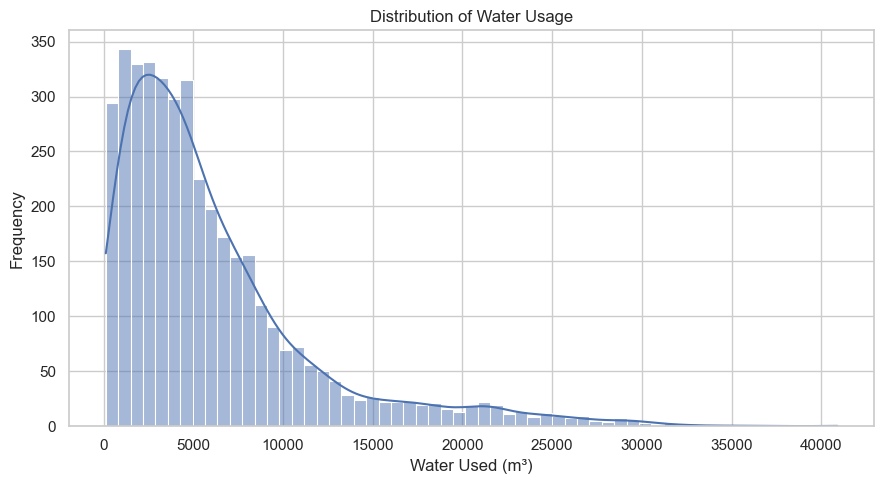

In [34]:
# Water usage distribution

plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Water_Used_m3",
    kde=True
)

plt.title("Distribution of Water Usage")
plt.xlabel("Water Used (m³)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [35]:
# IQR-based outlier analysis function

def calculate_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]
    
    return Q1, Q3, IQR, lower_bound, upper_bound, len(outliers)

In [36]:
# Calculate outliers for all numerical variables

outlier_results = []

for col in numeric_columns:
    
    Q1, Q3, IQR, lower, upper, count = calculate_outliers(df, col)
    
    outlier_results.append({
        "Column": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower_Bound": lower,
        "Upper_Bound": upper,
        "Outlier_Count": count,
        "Outlier_Percentage": (count / len(df)) * 100
    })

outlier_summary = pd.DataFrame(outlier_results)

outlier_summary = outlier_summary.sort_values(
    "Outlier_Count",
    ascending=False
)

outlier_summary.round(2)

,Column,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
18,Profit_INR,"-148,731.75","216,187.75","364,919.50","-696,111.00","763,567.00",404,10.10
14,Production_Tonnes,5.02,24.36,19.34,-23.98,53.36,333,8.33
20,Water_Efficiency_t_per_1000m3,1.66,5.15,3.49,-3.57,10.38,322,8.05
13,Yield_Tonnes_Ha,1.05,2.83,1.78,-1.62,5.50,302,7.55
19,Water_Used_m3,"2,268.75","7,829.75","5,561.00","-6,072.75","16,171.25",276,6.90
17,Revenue_INR,"207,517.25","836,874.75","629,357.50","-736,519.00","1,780,911.00",240,6.00
9,Potassium_kg_ha,86.20,123.60,37.40,30.10,179.70,32,0.80
4,Sunlight_Hours_Day,6.60,8.10,1.50,4.35,10.35,26,0.65
8,Phosphorus_kg_ha,46.20,69.40,23.20,11.40,104.20,16,0.40
10,Fertilizer_kg_ha,143.98,227.20,83.22,19.14,352.04,15,0.38


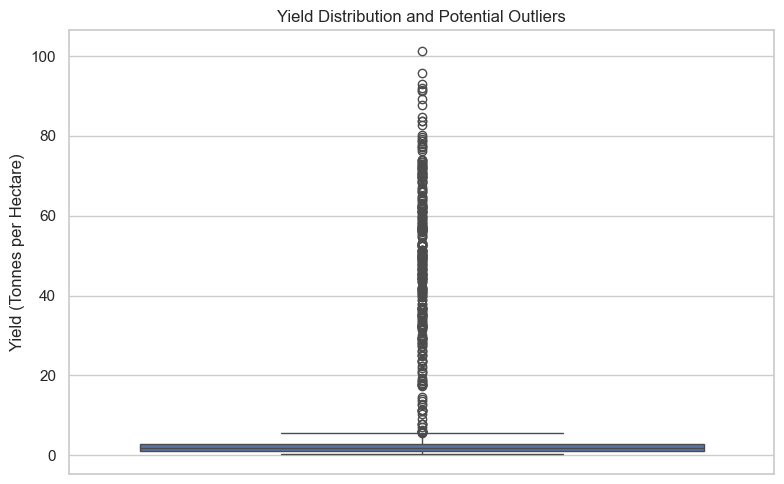

In [37]:
# Yield boxplot

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    y="Yield_Tonnes_Ha"
)

plt.title("Yield Distribution and Potential Outliers")
plt.ylabel("Yield (Tonnes per Hectare)")
plt.tight_layout()
plt.show()

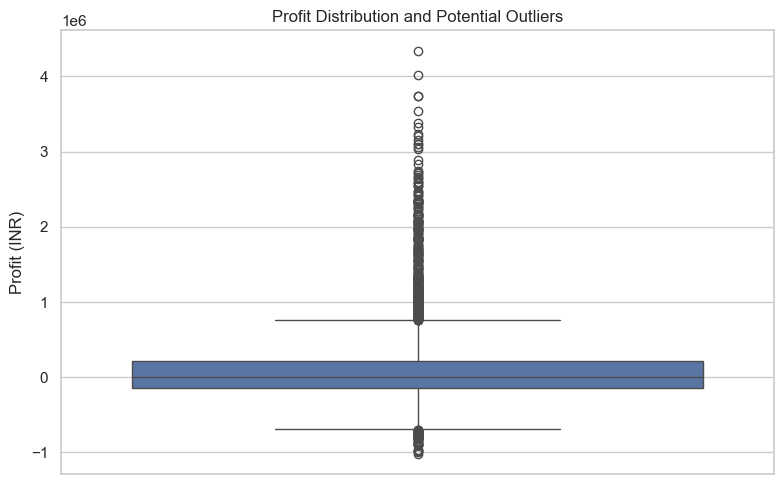

In [38]:
# Profit boxplot

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    y="Profit_INR"
)

plt.title("Profit Distribution and Potential Outliers")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()

In [39]:
# Detailed statistical summary

statistical_summary = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Standard_Deviation": df[numeric_columns].std(),
    "Minimum": df[numeric_columns].min(),
    "Maximum": df[numeric_columns].max()
})

statistical_summary

,Mean,Median,Standard_Deviation,Minimum,Maximum
Farm_Area_Hectares,7.89,7.89,4.22,0.50,15.00
Rainfall_mm,600.92,582.00,287.19,80.00,"1,395.20"
Avg_Temperature_C,26.82,26.90,3.82,16.20,39.70
Humidity_pct,63.21,63.00,11.96,25.00,95.00
Sunlight_Hours_Day,7.32,7.30,1.12,3.50,11.00
Soil_pH,6.70,6.69,0.64,5.20,8.40
Soil_Moisture_pct,26.51,26.40,6.68,8.00,47.00
Nitrogen_kg_ha,120.25,120.10,31.22,40.00,220.00
Phosphorus_kg_ha,57.78,57.50,17.02,15.00,120.00
Potassium_kg_ha,104.76,105.10,27.74,30.00,200.00


In [40]:
# Descriptive statistics by season

season_statistics = df.groupby("Season")[numeric_columns].agg(
    ["mean", "median", "std"]
)

season_statistics

Farm_Area_Hectares             Rainfall_mm                \
                     mean median  std        mean median    std   
Season                                                            
Kharif               7.94   8.18 4.28      849.20 853.10 183.69   
Rabi                 7.75   7.68 4.18      437.62 432.20 175.35   
Zaid                 8.09   8.09 4.16      304.65 288.20 157.24   

       Avg_Temperature_C             Humidity_pct              \
                    mean median  std         mean median  std   
Season                                                          
Kharif             28.45  28.50 2.51        71.81  71.90 8.86   
Rabi               23.49  23.50 2.46        57.89  58.10 9.00   
Zaid               31.04  31.00 2.55        52.01  52.35 9.05   

       Sunlight_Hours_Day             Soil_pH             Soil_Moisture_pct  \
                     mean median  std    mean median  std              mean   
Season                                                                        
Kharif               6.79   6.80 0.98    6.73   6.73 0.64             31.15   
Rabi                 7.59   7.60 1.00    6.67   6.67 0.64             24.07   
Zaid                 8.18   8.20 1.05    6.69   6.66 0.64             19.28   

                   Nitrogen_kg_ha              Phosphorus_kg_ha               \
       median  std           mean median   std             mean median   std   
Season                                                                         
Kharif  31.10 5.04         120.02 119.80 31.18            58.10  57.40 17.15   
Rabi    24.00 4.94         120.40 120.30 31.10            57.31  57.70 17.12   
Zaid    19.10 4.94         120.53 120.15 31.70            58.13  57.45 16.29   

       Potassium_kg_ha              Fertilizer_kg_ha               \
                  mean median   std             mean median   std   
Season                                                              
Kharif          105.30 104.80 27.03           187.08 188.20 60.82   
Rabi            103.93 104.80 28.87           185.41 185.30 59.95   
Zaid            105.42 106.30 26.66           184.64 183.95 59.47   

       Pesticide_Litre_ha             Seed_Quality_Score              \
                     mean median  std               mean median  std   
Season                                                                 
Kharif               5.08   5.18 1.96               0.82   0.82 0.10   
Rabi                 5.02   5.02 1.99               0.83   0.84 0.10   
Zaid                 5.17   5.19 1.99               0.82   0.83 0.10   

       Yield_Tonnes_Ha              Production_Tonnes                \
                  mean median   std              mean median    std   
Season                                                                
Kharif            5.63   1.94 14.39             46.31  13.24 135.70   
Rabi              5.04   1.67 12.75             41.49  11.08 121.90   
Zaid              4.64   1.46 11.27             38.89   9.97 112.00   

       Market_Price_INR_Tonne                     Total_Cost_INR             \
                         mean    median       std           mean     median   
Season                                                                        
Kharif              44,850.91 25,793.00 30,301.56     531,804.41 524,840.00   
Rabi                44,747.97 26,041.00 30,309.56     513,836.58 506,733.00   
Zaid                44,212.03 25,749.50 30,086.23     543,976.73 534,833.00   

                  Revenue_INR                       Profit_INR             \
              std        mean     median        std       mean     median   
Season                                                                      
Kharif 298,487.69  710,719.06 520,196.00 708,710.37 178,914.65  38,808.00   
Rabi   288,386.89  601,526.05 438,156.00 584,545.52  87,689.47  -3,187.00   
Zaid   297,576.86  519,171.90 373,700.50 509,524.55 -24,804.82 -62,144.00   

                  Water_Used_m3             

In [41]:
# Seasonal performance summary

season_metrics = df.groupby("Season").agg(
    Records=("Farm_ID", "count"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Total_Production=("Production_Tonnes", "sum"),
    Average_Production=("Production_Tonnes", "mean"),
    Average_Revenue=("Revenue_INR", "mean"),
    Total_Revenue=("Revenue_INR", "sum"),
    Average_Cost=("Total_Cost_INR", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Total_Profit=("Profit_INR", "sum"),
    Average_Water_Used=("Water_Used_m3", "mean"),
    Average_Rainfall=("Rainfall_mm", "mean"),
    Average_Disease_Risk=("Disease_Pest_Risk_pct", "mean")
).round(2)

season_metrics

,Records,Average_Yield,Total_Production,Average_Production,Average_Revenue,Total_Revenue,Average_Cost,Average_Profit,Total_Profit,Average_Water_Used,Average_Rainfall,Average_Disease_Risk
Season,,,,,,,,,,,,
Kharif,1779,5.63,"82,387.61",46.31,"710,719.06",1264369200,"531,804.41","178,914.65",318289158,"6,102.20",849.20,54.47
Rabi,1627,5.04,"67,498.88",41.49,"601,526.05",978682881,"513,836.58","87,689.47",142670768,"5,846.99",437.62,40.48
Zaid,594,4.64,"23,098.35",38.89,"519,171.90",308388111,"543,976.73","-24,804.82",-14734066,"6,419.89",304.65,38.22


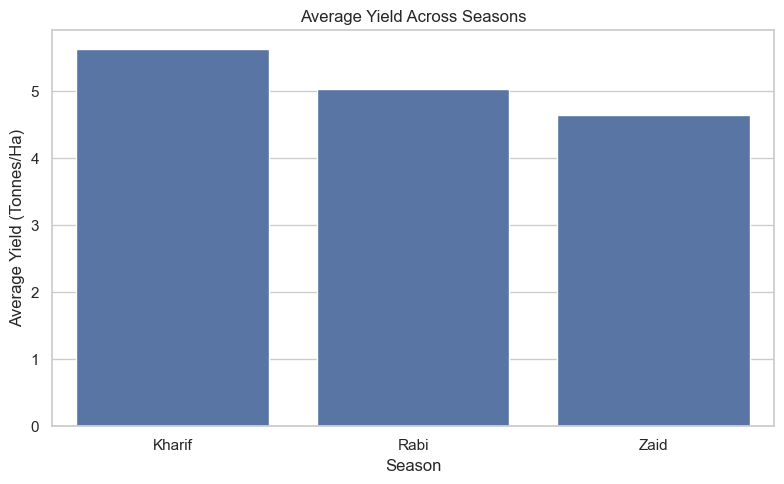

In [42]:
# Average yield by season

yield_by_season = (
    df.groupby("Season")["Yield_Tonnes_Ha"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=yield_by_season.index,
    y=yield_by_season.values
)

plt.title("Average Yield Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

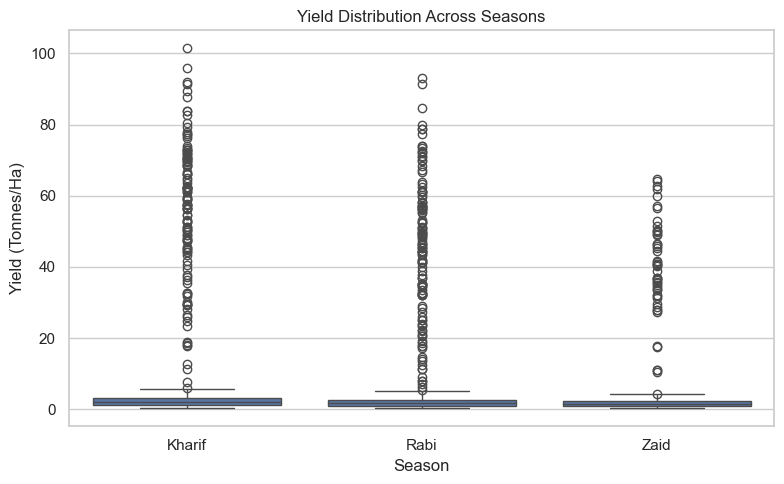

In [43]:
# Yield distribution across seasons

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Season",
    y="Yield_Tonnes_Ha"
)

plt.title("Yield Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

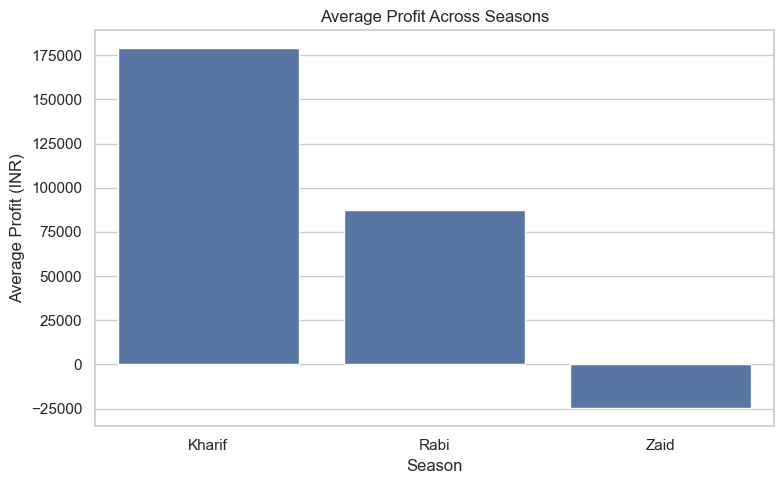

In [44]:
# Average profit by season

profit_by_season = (
    df.groupby("Season")["Profit_INR"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=profit_by_season.index,
    y=profit_by_season.values
)

plt.title("Average Profit Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.tight_layout()
plt.show()

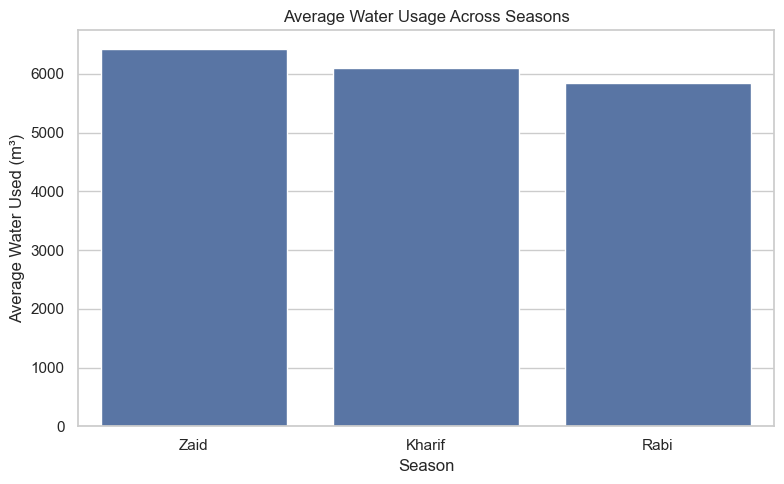

In [45]:
# Average water usage by season

water_by_season = (
    df.groupby("Season")["Water_Used_m3"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=water_by_season.index,
    y=water_by_season.values
)

plt.title("Average Water Usage Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Water Used (m³)")
plt.tight_layout()
plt.show()

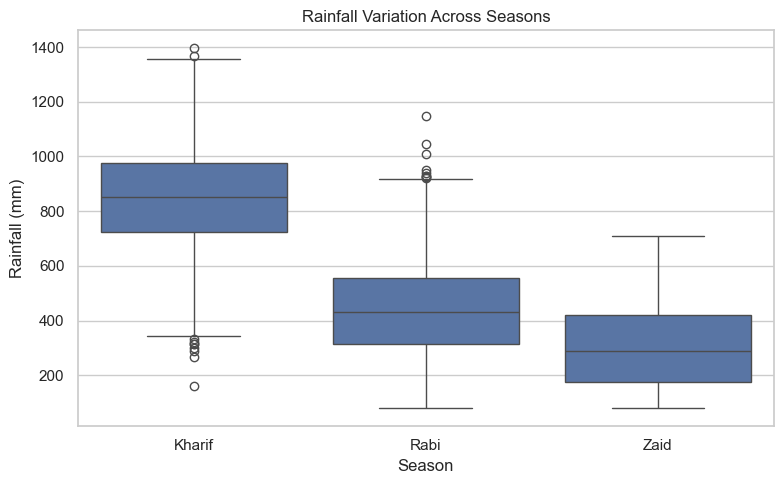

In [46]:
# Rainfall across seasons

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Season",
    y="Rainfall_mm"
)

plt.title("Rainfall Variation Across Seasons")
plt.xlabel("Season")
plt.ylabel("Rainfall (mm)")
plt.tight_layout()
plt.show()

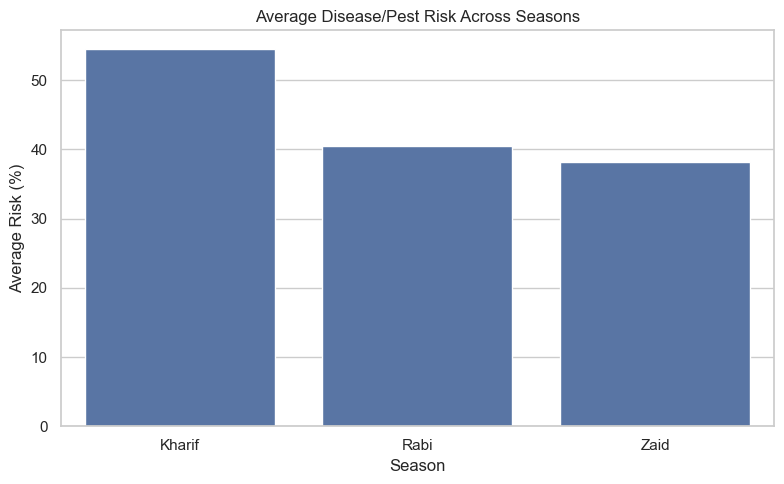

In [47]:
# Disease and pest risk across seasons

risk_by_season = (
    df.groupby("Season")["Disease_Pest_Risk_pct"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=risk_by_season.index,
    y=risk_by_season.values
)

plt.title("Average Disease/Pest Risk Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Risk (%)")
plt.tight_layout()
plt.show()

In [48]:
# Crop performance by season

crop_season_summary = (
    df.groupby(["Crop", "Season"])
    .agg(
        Average_Yield=("Yield_Tonnes_Ha", "mean"),
        Average_Profit=("Profit_INR", "mean"),
        Average_Water_Efficiency=(
            "Water_Efficiency_t_per_1000m3",
            "mean"
        ),
        Records=("Farm_ID", "count")
    )
    .reset_index()
)

crop_season_summary.round(2)

,Crop,Season,Average_Yield,Average_Profit,Average_Water_Efficiency,Records
0,Chilli,Kharif,1.73,"954,380.42",3.26,185
1,Chilli,Rabi,1.47,"638,572.50",2.89,163
2,Chilli,Zaid,1.20,"448,659.09",2.20,64
3,Cotton,Kharif,1.37,"216,999.55",2.13,215
4,Cotton,Rabi,1.20,"107,343.59",1.94,201
5,Cotton,Zaid,0.96,"-53,925.34",1.49,92
6,Groundnut,Kharif,1.48,"108,265.44",3.58,193
7,Groundnut,Rabi,1.23,"10,416.54",2.90,177
8,Groundnut,Zaid,1.04,"-68,872.50",2.47,54
9,Maize,Kharif,2.97,"-39,332.67",6.05,234


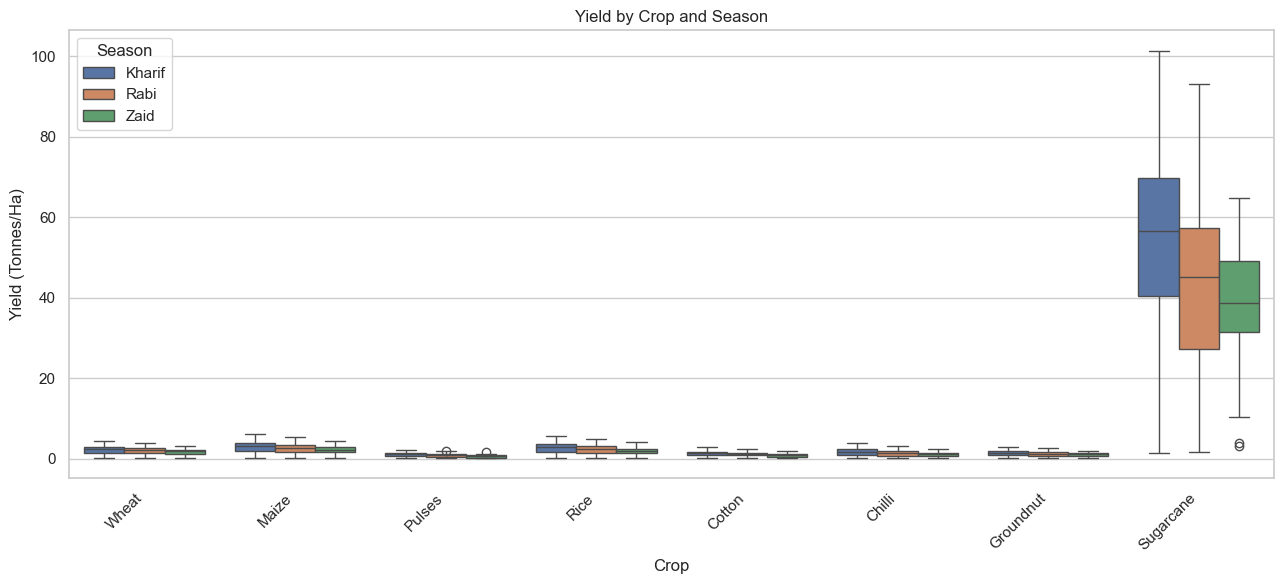

In [49]:
# Yield by crop and season

plt.figure(figsize=(13, 6))

sns.boxplot(
    data=df,
    x="Crop",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Yield by Crop and Season")
plt.xlabel("Crop")
plt.ylabel("Yield (Tonnes/Ha)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

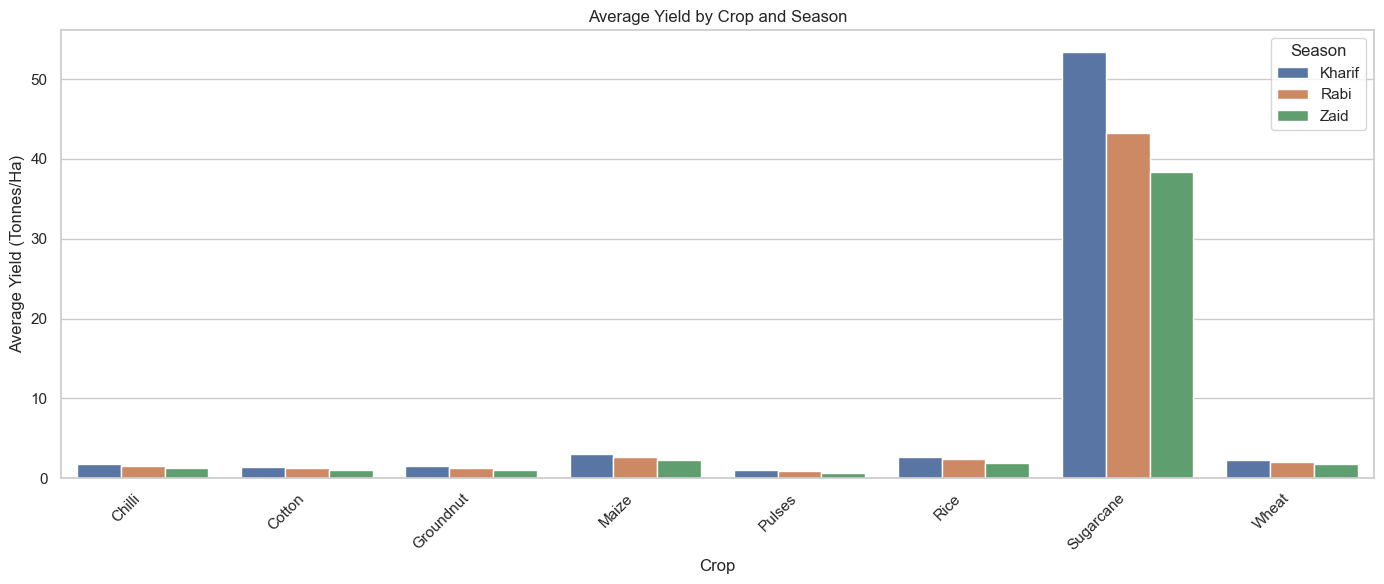

In [50]:
# Average yield by crop and season

plt.figure(figsize=(14, 6))

sns.barplot(
    data=crop_season_summary,
    x="Crop",
    y="Average_Yield",
    hue="Season"
)

plt.title("Average Yield by Crop and Season")
plt.xlabel("Crop")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

In [51]:
# Irrigation method performance

irrigation_summary = (
    df.groupby("Irrigation_Method")
    .agg(
        Average_Yield=("Yield_Tonnes_Ha", "mean"),
        Average_Profit=("Profit_INR", "mean"),
        Average_Water_Used=("Water_Used_m3", "mean"),
        Average_Water_Efficiency=(
            "Water_Efficiency_t_per_1000m3",
            "mean"
        ),
        Records=("Farm_ID", "count")
    )
    .sort_values("Average_Yield", ascending=False)
)

irrigation_summary.round(2)

,Average_Yield,Average_Profit,Average_Water_Used,Average_Water_Efficiency,Records
Irrigation_Method,,,,,
Drip,6.58,"219,626.00","5,918.75",6.27,915
Sprinkler,5.16,"91,121.08","6,208.26",4.67,734
Flood,4.86,"73,354.02","8,026.47",3.44,1310
Rainfed,4.60,"79,050.37","3,549.55",7.56,1041


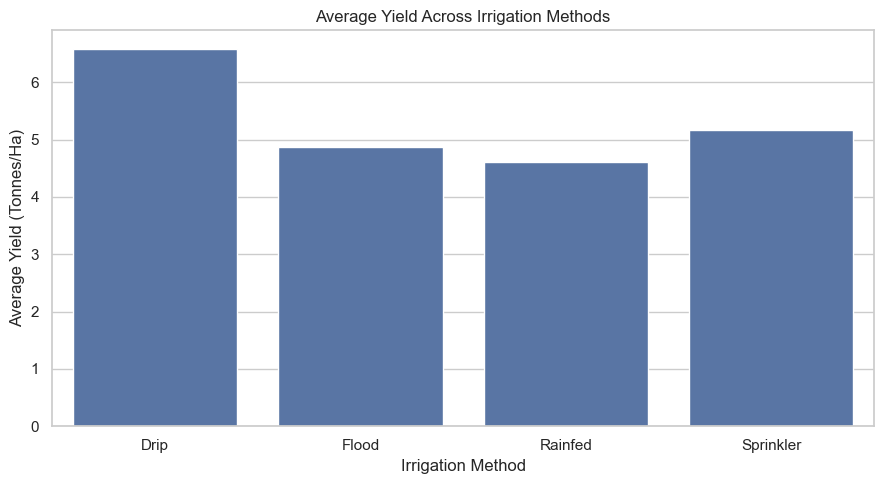

In [52]:
# Yield across irrigation methods

plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x="Irrigation_Method",
    y="Yield_Tonnes_Ha",
    errorbar=None
)

plt.title("Average Yield Across Irrigation Methods")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

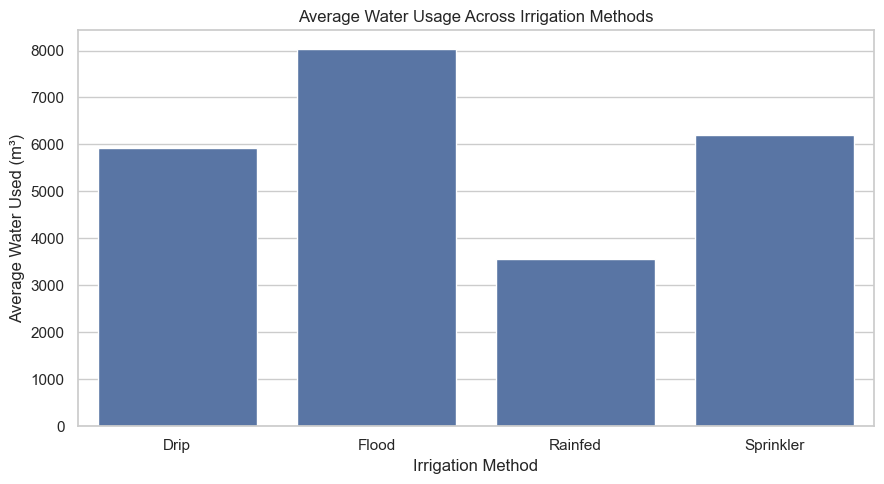

In [53]:
# Water usage by irrigation method

plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x="Irrigation_Method",
    y="Water_Used_m3",
    errorbar=None
)

plt.title("Average Water Usage Across Irrigation Methods")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Water Used (m³)")
plt.tight_layout()
plt.show()

## 4. Student-Designed Analysis 1
### Question:
How does agricultural performance vary across different states?

### Why is this relevant?

Agricultural performance may differ geographically because farms operate under
different environmental conditions, crops, resource availability and practices.
Comparing states helps identify regions with relatively stronger or weaker
performance.

In [55]:
# State-wise agricultural performance

state_summary = (
    df.groupby("State")
    .agg(
        Records=("Farm_ID", "count"),
        Average_Yield=("Yield_Tonnes_Ha", "mean"),
        Average_Profit=("Profit_INR", "mean"),
        Average_Revenue=("Revenue_INR", "mean"),
        Average_Water_Used=("Water_Used_m3", "mean"),
        Average_Disease_Risk=("Disease_Pest_Risk_pct", "mean")
    )
    .sort_values("Average_Profit", ascending=False)
)

state_summary.round(2)

,Records,Average_Yield,Average_Profit,Average_Revenue,Average_Water_Used,Average_Disease_Risk
State,,,,,,
Punjab,484,6.12,"136,025.64","686,225.70","6,565.92",46.00
Maharashtra,512,5.02,"135,428.86","650,032.67","5,968.08",46.44
Karnataka,489,5.69,"119,422.34","653,426.18","6,414.33",46.06
Tamil Nadu,485,4.88,"117,744.75","629,093.42","5,775.22",46.28
Gujarat,488,5.66,"117,568.24","654,692.86","6,142.50",45.95
Telangana,516,5.04,"108,829.62","628,784.53","5,801.83",46.36
Madhya Pradesh,497,4.99,"86,840.76","597,558.36","5,663.92",47.08
Andhra Pradesh,529,4.63,"73,453.53","606,663.66","6,058.38",46.72


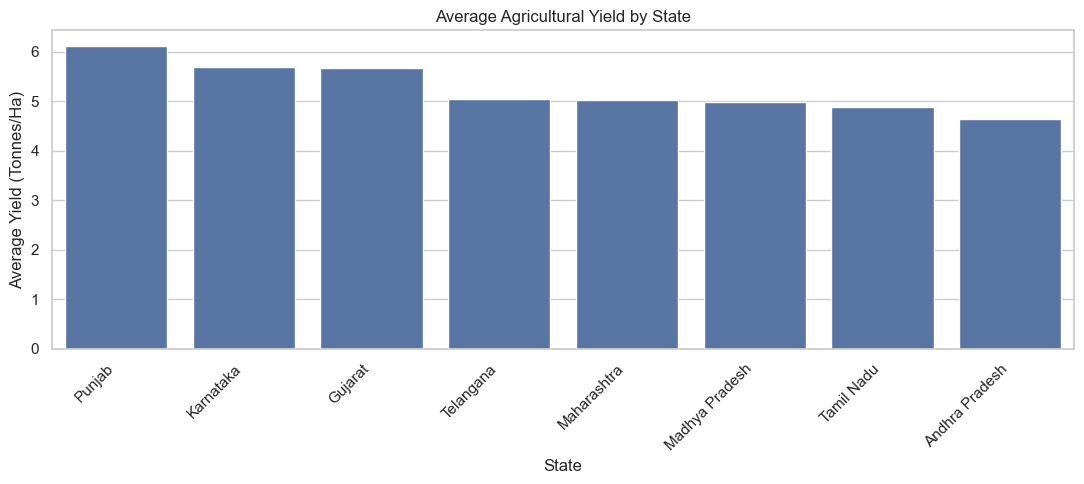

In [56]:
# Average yield by state

state_yield = (
    df.groupby("State")["Yield_Tonnes_Ha"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(11, 5))

sns.barplot(
    x=state_yield.index,
    y=state_yield.values
)

plt.title("Average Agricultural Yield by State")
plt.xlabel("State")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

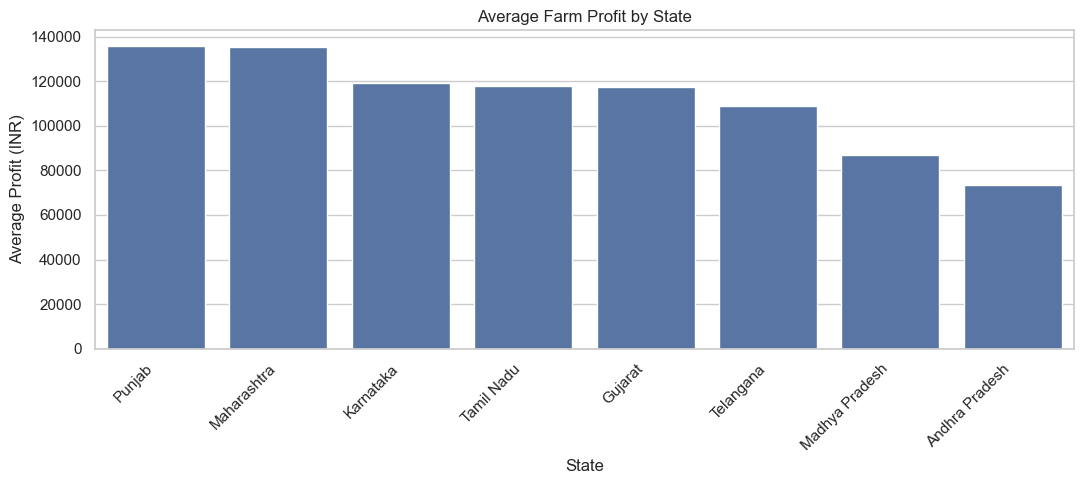

In [57]:
# Average profit by state

state_profit = (
    df.groupby("State")["Profit_INR"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(11, 5))

sns.barplot(
    x=state_profit.index,
    y=state_profit.values
)

plt.title("Average Farm Profit by State")
plt.xlabel("State")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 5. Student-Designed Analysis 2
### Question:
What relationships exist between environmental conditions and agricultural yield?

The analysis focuses on rainfall, temperature, humidity, soil moisture and
sunlight because these variables represent environmental conditions that may
vary across seasons and agricultural locations.

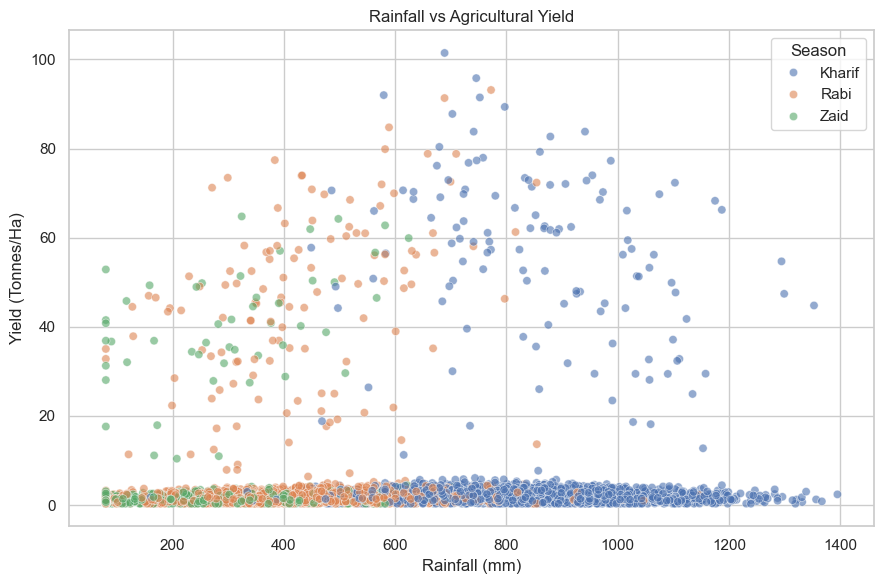

In [59]:
# Rainfall vs yield

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season",
    alpha=0.6
)

plt.title("Rainfall vs Agricultural Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

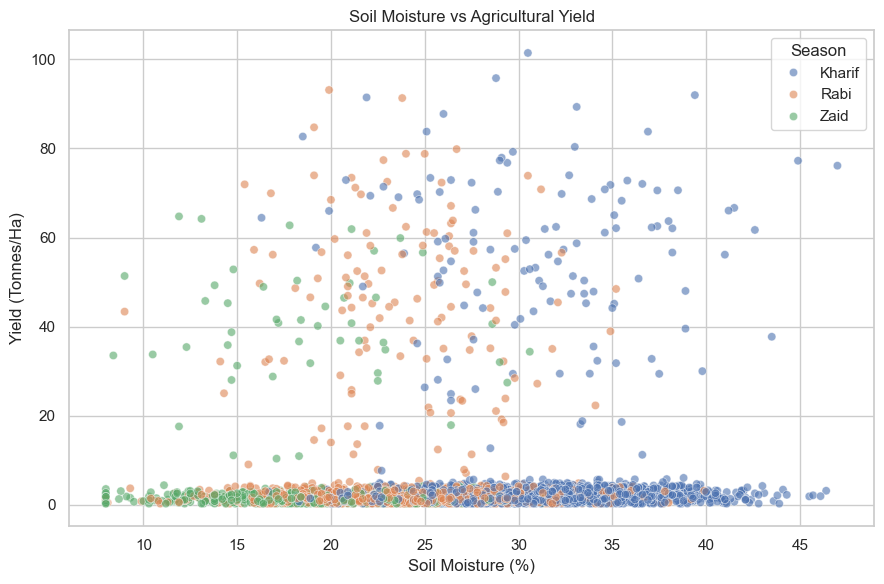

In [60]:
# Soil moisture vs yield

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Soil_Moisture_pct",
    y="Yield_Tonnes_Ha",
    hue="Season",
    alpha=0.6
)

plt.title("Soil Moisture vs Agricultural Yield")
plt.xlabel("Soil Moisture (%)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

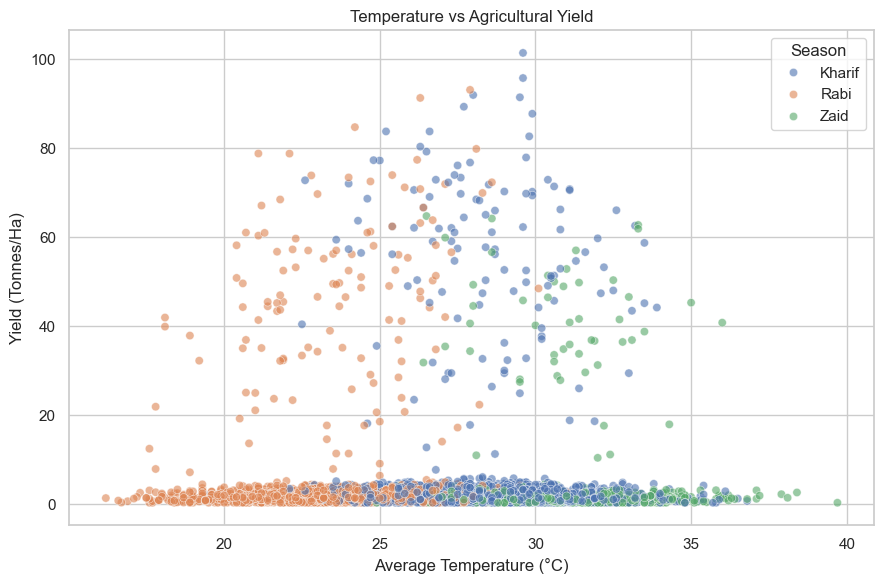

In [61]:
# Temperature vs yield

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Avg_Temperature_C",
    y="Yield_Tonnes_Ha",
    hue="Season",
    alpha=0.6
)

plt.title("Temperature vs Agricultural Yield")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

In [62]:
# Calculate correlation matrix

correlation_matrix = df[numeric_columns].corr()

correlation_matrix.round(2)

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Farm_Area_Hectares,1.00,0.01,0.04,0.00,0.00,0.01,0.00,0.01,-0.01,0.00,0.01,-0.01,0.02,0.03,0.20,-0.02,0.96,0.54,0.12,0.58,0.03,0.03
Rainfall_mm,0.01,1.00,0.20,0.52,-0.36,0.02,0.51,0.01,0.02,0.03,0.02,0.00,-0.02,0.03,0.02,0.00,0.01,0.10,0.11,0.00,0.06,0.62
Avg_Temperature_C,0.04,0.20,1.00,0.14,-0.03,0.03,0.08,0.02,0.01,0.02,0.02,0.01,-0.03,0.01,0.01,0.00,0.04,0.03,0.01,0.02,0.01,0.25
Humidity_pct,0.00,0.52,0.14,1.00,-0.30,0.03,0.45,0.00,-0.01,-0.00,0.02,-0.00,-0.05,0.01,0.00,0.00,0.01,0.06,0.06,-0.00,0.03,0.55
Sunlight_Hours_Day,0.00,-0.36,-0.03,-0.30,1.00,-0.02,-0.30,0.01,0.00,-0.01,-0.01,-0.02,0.02,-0.02,-0.02,-0.00,-0.00,-0.05,-0.05,-0.01,-0.02,-0.25
Soil_pH,0.01,0.02,0.03,0.03,-0.02,1.00,0.03,0.01,0.02,-0.02,-0.01,-0.01,-0.00,-0.02,-0.01,0.02,0.01,-0.01,-0.01,-0.02,-0.01,0.03
Soil_Moisture_pct,0.00,0.51,0.08,0.45,-0.30,0.03,1.00,0.01,0.01,0.01,0.01,-0.02,-0.02,0.01,0.00,0.02,0.00,0.08,0.09,0.00,0.03,0.38
Nitrogen_kg_ha,0.01,0.01,0.02,0.00,0.01,0.01,0.01,1.00,0.01,0.01,-0.03,0.01,0.01,0.05,0.05,-0.02,0.01,0.08,0.09,0.02,0.05,-0.01
Phosphorus_kg_ha,-0.01,0.02,0.01,-0.01,0.00,0.02,0.01,0.01,1.00,0.00,0.01,-0.03,-0.01,0.05,0.03,-0.01,-0.02,0.03,0.05,-0.00,0.06,0.03
Potassium_kg_ha,0.00,0.03,0.02,-0.00,-0.01,-0.02,0.01,0.01,0.00,1.00,0.02,-0.00,0.01,0.00,0.00,0.01,0.00,0.03,0.03,0.00,0.01,0.01


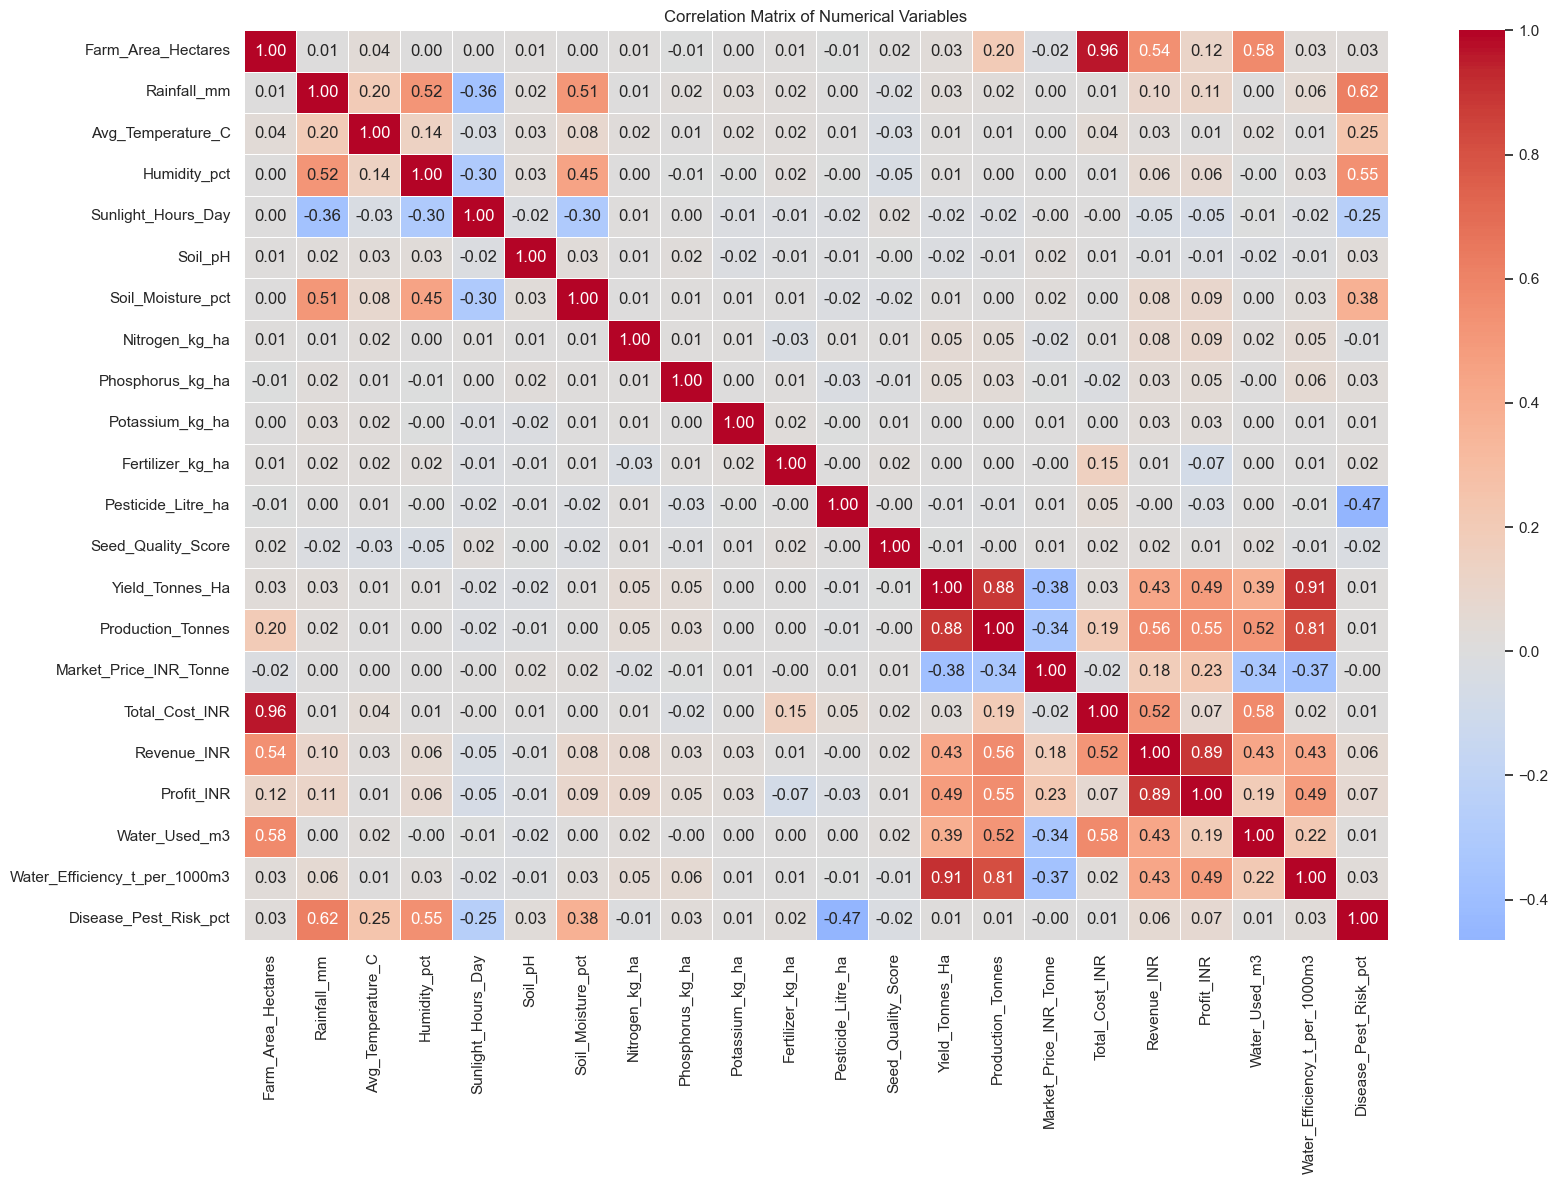

In [63]:
# Correlation heatmap

plt.figure(figsize=(17, 12))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

In [64]:
# Correlation of all numerical variables with yield

yield_correlations = (
    correlation_matrix["Yield_Tonnes_Ha"]
    .sort_values(ascending=False)
)

yield_correlations

Yield_Tonnes_Ha                  1.00
Water_Efficiency_t_per_1000m3    0.91
Production_Tonnes                0.88
Profit_INR                       0.49
Revenue_INR                      0.43
Water_Used_m3                    0.39
Nitrogen_kg_ha                   0.05
Phosphorus_kg_ha                 0.05
Rainfall_mm                      0.03
Total_Cost_INR                   0.03
Farm_Area_Hectares               0.03
Disease_Pest_Risk_pct            0.01
Humidity_pct                     0.01
Soil_Moisture_pct                0.01
Avg_Temperature_C                0.01
Potassium_kg_ha                  0.00
Fertilizer_kg_ha                 0.00
Seed_Quality_Score              -0.01
Pesticide_Litre_ha              -0.01
Sunlight_Hours_Day              -0.02
Soil_pH                         -0.02
Market_Price_INR_Tonne          -0.38
Name: Yield_Tonnes_Ha, dtype: float64

In [65]:
# Correlation of variables with profit

profit_correlations = (
    correlation_matrix["Profit_INR"]
    .sort_values(ascending=False)
)

profit_correlations

Profit_INR                       1.00
Revenue_INR                      0.89
Production_Tonnes                0.55
Water_Efficiency_t_per_1000m3    0.49
Yield_Tonnes_Ha                  0.49
Market_Price_INR_Tonne           0.23
Water_Used_m3                    0.19
Farm_Area_Hectares               0.12
Rainfall_mm                      0.11
Soil_Moisture_pct                0.09
Nitrogen_kg_ha                   0.09
Total_Cost_INR                   0.07
Disease_Pest_Risk_pct            0.07
Humidity_pct                     0.06
Phosphorus_kg_ha                 0.05
Potassium_kg_ha                  0.03
Seed_Quality_Score               0.01
Avg_Temperature_C                0.01
Soil_pH                         -0.01
Pesticide_Litre_ha              -0.03
Sunlight_Hours_Day              -0.05
Fertilizer_kg_ha                -0.07
Name: Profit_INR, dtype: float64

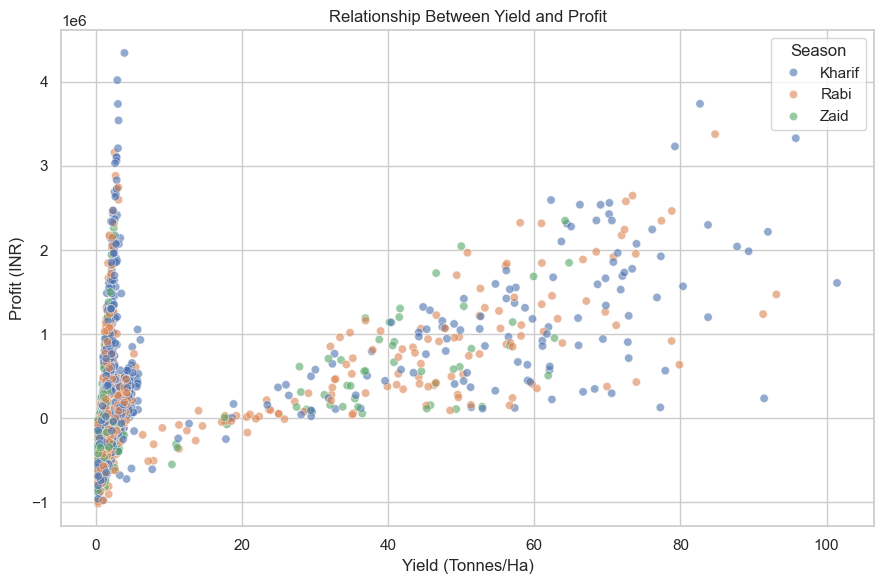

In [66]:
# Relationship between yield and profit

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Yield_Tonnes_Ha",
    y="Profit_INR",
    hue="Season",
    alpha=0.6
)

plt.title("Relationship Between Yield and Profit")
plt.xlabel("Yield (Tonnes/Ha)")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()

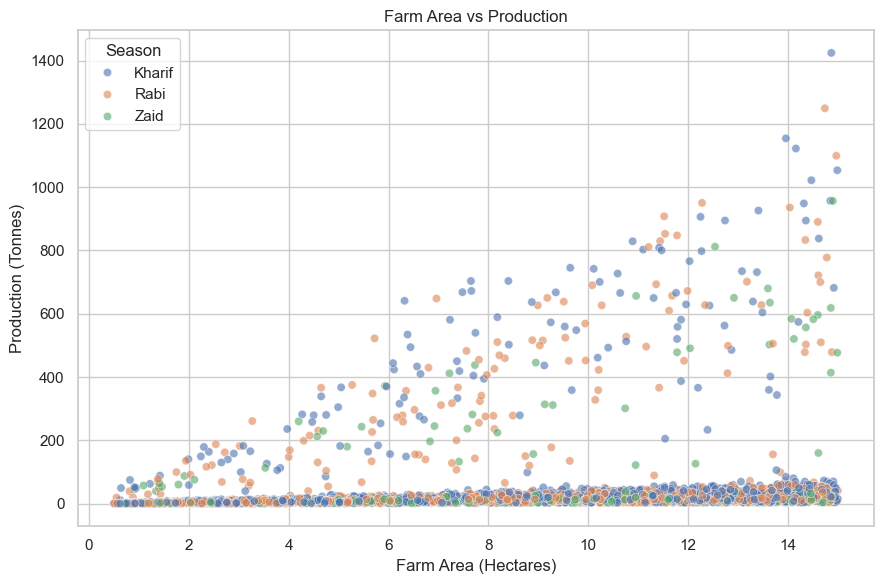

In [67]:
# Farm area vs production

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Farm_Area_Hectares",
    y="Production_Tonnes",
    hue="Season",
    alpha=0.6
)

plt.title("Farm Area vs Production")
plt.xlabel("Farm Area (Hectares)")
plt.ylabel("Production (Tonnes)")
plt.tight_layout()
plt.show()

## 6. Student-Designed Analysis 3
### Question:
Which seasons and irrigation methods show better water efficiency?

Water availability is an important agricultural resource. Water efficiency
helps compare production performance relative to water usage.

In [69]:
# Water efficiency by season

season_water_efficiency = (
    df.groupby("Season")["Water_Efficiency_t_per_1000m3"]
    .mean()
    .sort_values(ascending=False)
)

season_water_efficiency.round(2)

Season
Kharif   5.89
Rabi     5.19
Zaid     4.41
Name: Water_Efficiency_t_per_1000m3, dtype: float64

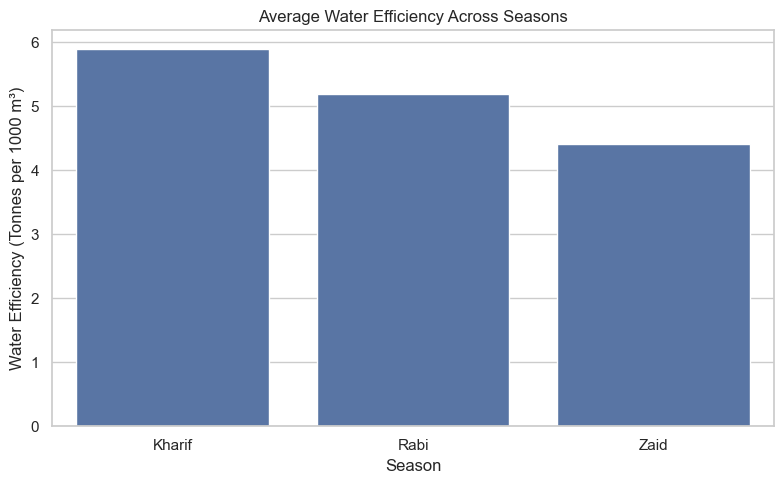

In [70]:
# Water efficiency across seasons

plt.figure(figsize=(8, 5))

sns.barplot(
    x=season_water_efficiency.index,
    y=season_water_efficiency.values
)

plt.title("Average Water Efficiency Across Seasons")
plt.xlabel("Season")
plt.ylabel("Water Efficiency (Tonnes per 1000 m³)")
plt.tight_layout()
plt.show()

In [71]:
# Water efficiency by irrigation method

irrigation_water_efficiency = (
    df.groupby("Irrigation_Method")
    ["Water_Efficiency_t_per_1000m3"]
    .mean()
    .sort_values(ascending=False)
)

irrigation_water_efficiency.round(2)

Irrigation_Method
Rainfed     7.56
Drip        6.27
Sprinkler   4.67
Flood       3.44
Name: Water_Efficiency_t_per_1000m3, dtype: float64

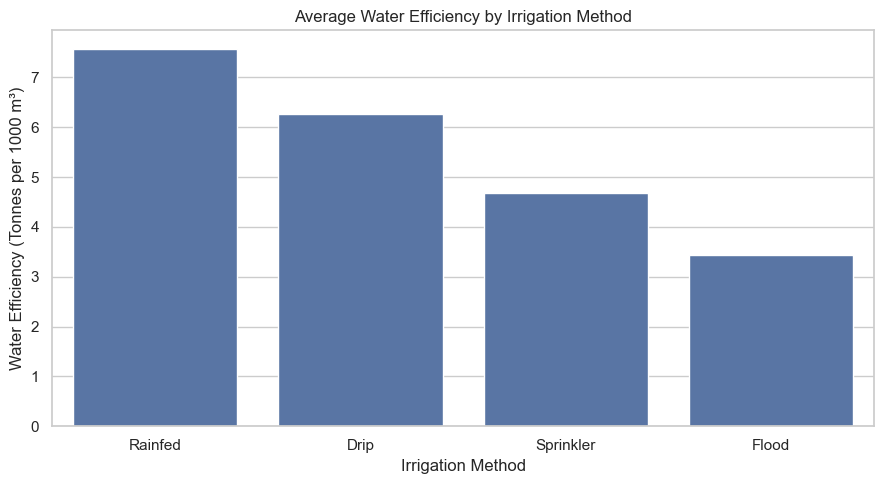

In [72]:
# Water efficiency by irrigation method

plt.figure(figsize=(9, 5))

sns.barplot(
    x=irrigation_water_efficiency.index,
    y=irrigation_water_efficiency.values
)

plt.title("Average Water Efficiency by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Water Efficiency (Tonnes per 1000 m³)")
plt.tight_layout()
plt.show()

## 7. Economic Performance Analysis

This section examines cost, revenue and profit across seasons and crops to
understand the economic side of agricultural performance.

In [74]:
# Economic performance by season

economic_season = (
    df.groupby("Season")
    .agg(
        Average_Cost=("Total_Cost_INR", "mean"),
        Average_Revenue=("Revenue_INR", "mean"),
        Average_Profit=("Profit_INR", "mean")
    )
    .round(2)
)

economic_season

,Average_Cost,Average_Revenue,Average_Profit
Season,,,
Kharif,"531,804.41","710,719.06","178,914.65"
Rabi,"513,836.58","601,526.05","87,689.47"
Zaid,"543,976.73","519,171.90","-24,804.82"


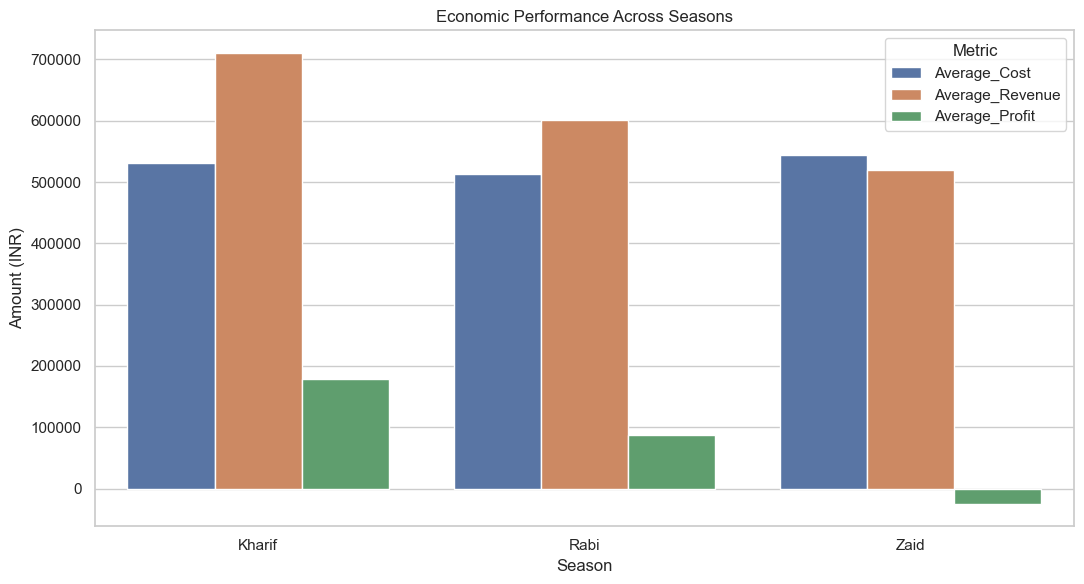

In [75]:
# Convert economic summary into long format for visualization

economic_plot = economic_season.reset_index().melt(
    id_vars="Season",
    var_name="Metric",
    value_name="Value"
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=economic_plot,
    x="Season",
    y="Value",
    hue="Metric"
)

plt.title("Economic Performance Across Seasons")
plt.xlabel("Season")
plt.ylabel("Amount (INR)")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

In [76]:
# Average profit by crop

crop_profit = (
    df.groupby("Crop")["Profit_INR"]
    .mean()
    .sort_values(ascending=False)
)

crop_profit.round(2)

Crop
Sugarcane    817,187.99
Chilli       750,878.34
Cotton       124,546.92
Groundnut     44,858.12
Pulses        -4,238.05
Maize        -83,978.33
Rice        -102,213.50
Wheat       -123,398.34
Name: Profit_INR, dtype: float64

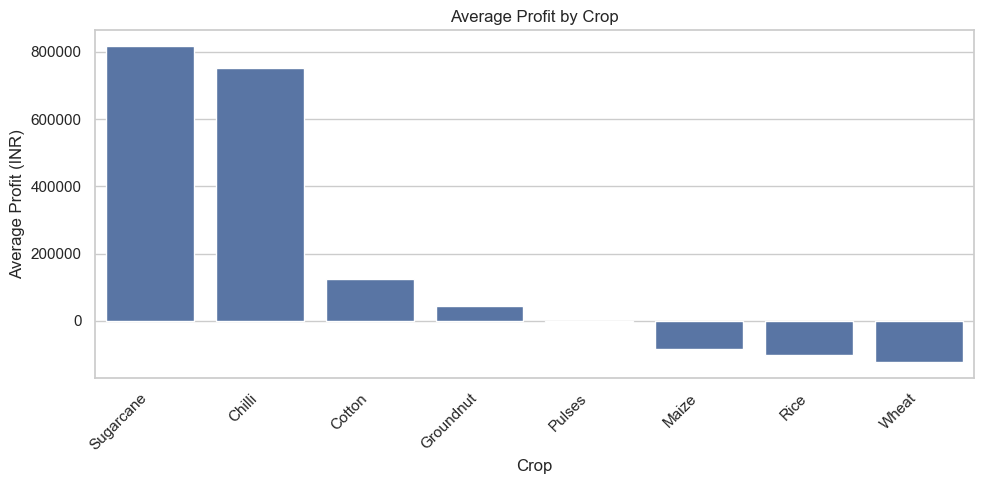

In [77]:
# Crop profitability

plt.figure(figsize=(10, 5))

sns.barplot(
    x=crop_profit.index,
    y=crop_profit.values
)

plt.title("Average Profit by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 8. Disease and Pest Risk Analysis

Disease and pest risk can be an important factor when comparing seasonal
agricultural conditions. This section identifies seasonal and crop-level
variation in reported risk.

In [79]:
# Average disease/pest risk by crop and season

risk_crop_season = (
    df.groupby(["Crop", "Season"])["Disease_Pest_Risk_pct"]
    .mean()
    .reset_index()
)

risk_crop_season.round(2)

,Crop,Season,Disease_Pest_Risk_pct
0,Chilli,Kharif,52.81
1,Chilli,Rabi,40.59
2,Chilli,Zaid,40.50
3,Cotton,Kharif,54.24
4,Cotton,Rabi,41.54
5,Cotton,Zaid,36.34
6,Groundnut,Kharif,54.28
7,Groundnut,Rabi,39.76
8,Groundnut,Zaid,39.13
9,Maize,Kharif,54.82


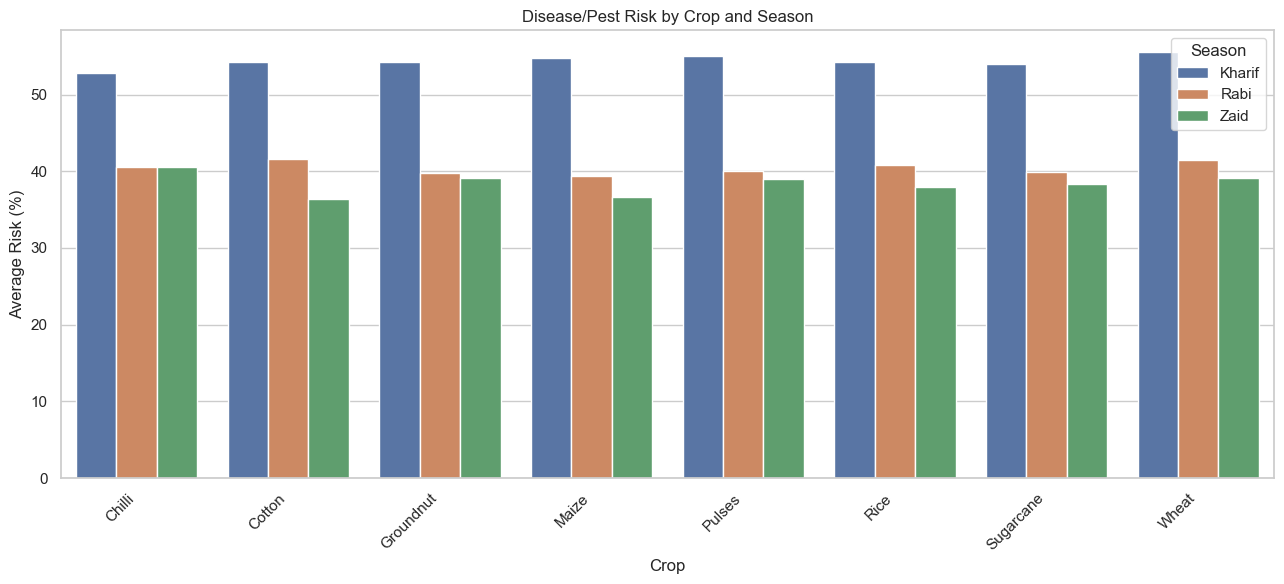

In [80]:
# Disease/pest risk by crop and season

plt.figure(figsize=(13, 6))

sns.barplot(
    data=risk_crop_season,
    x="Crop",
    y="Disease_Pest_Risk_pct",
    hue="Season"
)

plt.title("Disease/Pest Risk by Crop and Season")
plt.xlabel("Crop")
plt.ylabel("Average Risk (%)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

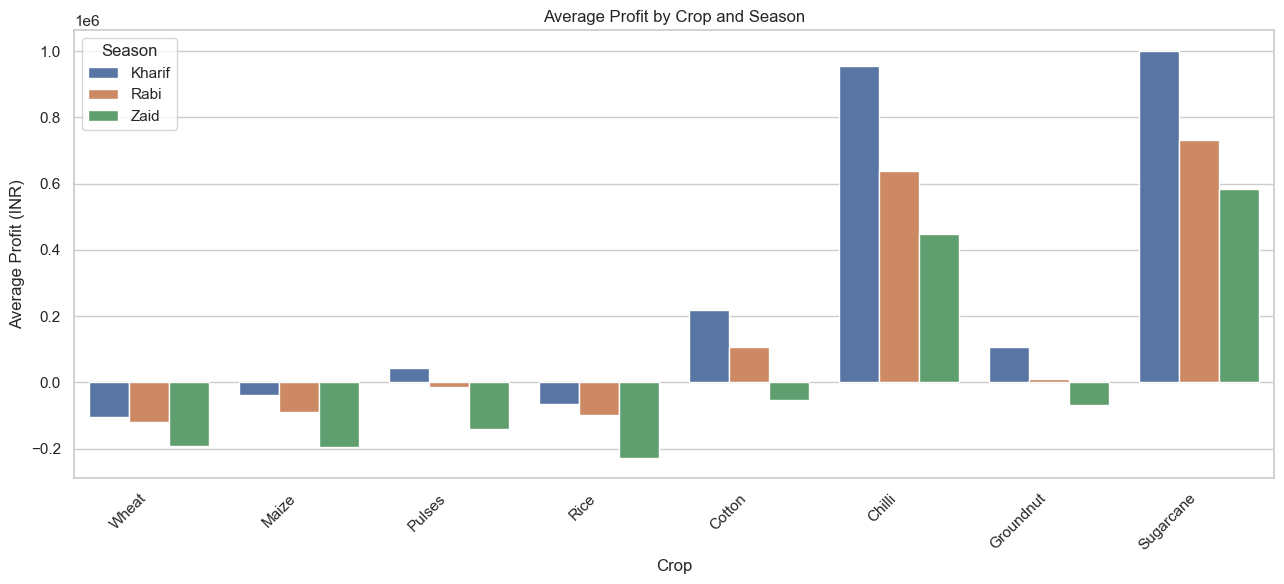

In [81]:
# Profit by crop and season

plt.figure(figsize=(13, 6))

sns.barplot(
    data=df,
    x="Crop",
    y="Profit_INR",
    hue="Season",
    errorbar=None
)

plt.title("Average Profit by Crop and Season")
plt.xlabel("Crop")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

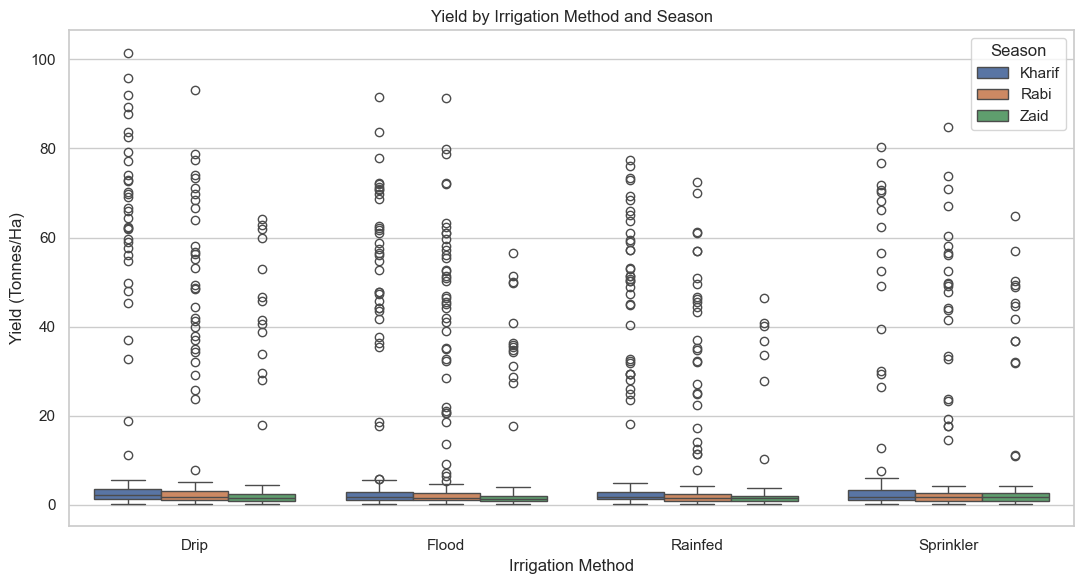

In [82]:
# Yield by irrigation method and season

plt.figure(figsize=(11, 6))

sns.boxplot(
    data=df,
    x="Irrigation_Method",
    y="Yield_Tonnes_Ha",
    hue="Season"
)

plt.title("Yield by Irrigation Method and Season")
plt.xlabel("Irrigation Method")
plt.ylabel("Yield (Tonnes/Ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

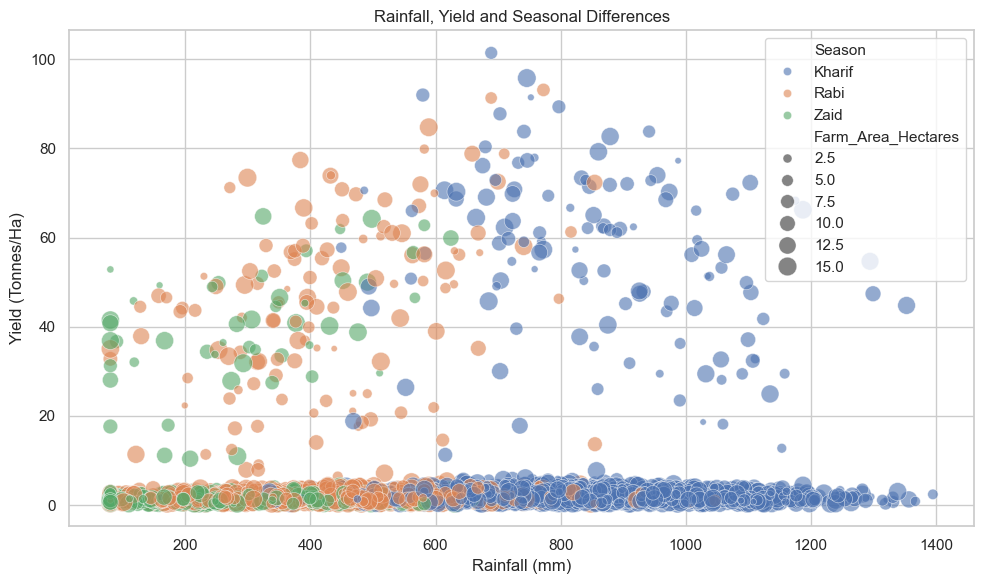

In [83]:
# Rainfall, yield and season

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season",
    size="Farm_Area_Hectares",
    sizes=(20, 180),
    alpha=0.6
)

plt.title("Rainfall, Yield and Seasonal Differences")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.tight_layout()
plt.show()

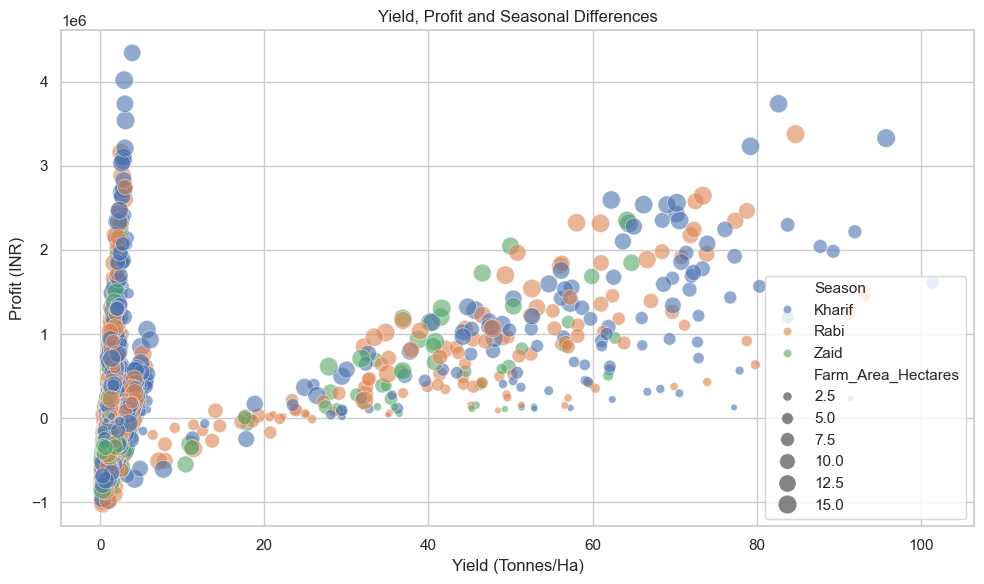

In [84]:
# Yield, profit and season

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Yield_Tonnes_Ha",
    y="Profit_INR",
    hue="Season",
    size="Farm_Area_Hectares",
    sizes=(20, 180),
    alpha=0.6
)

plt.title("Yield, Profit and Seasonal Differences")
plt.xlabel("Yield (Tonnes/Ha)")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()

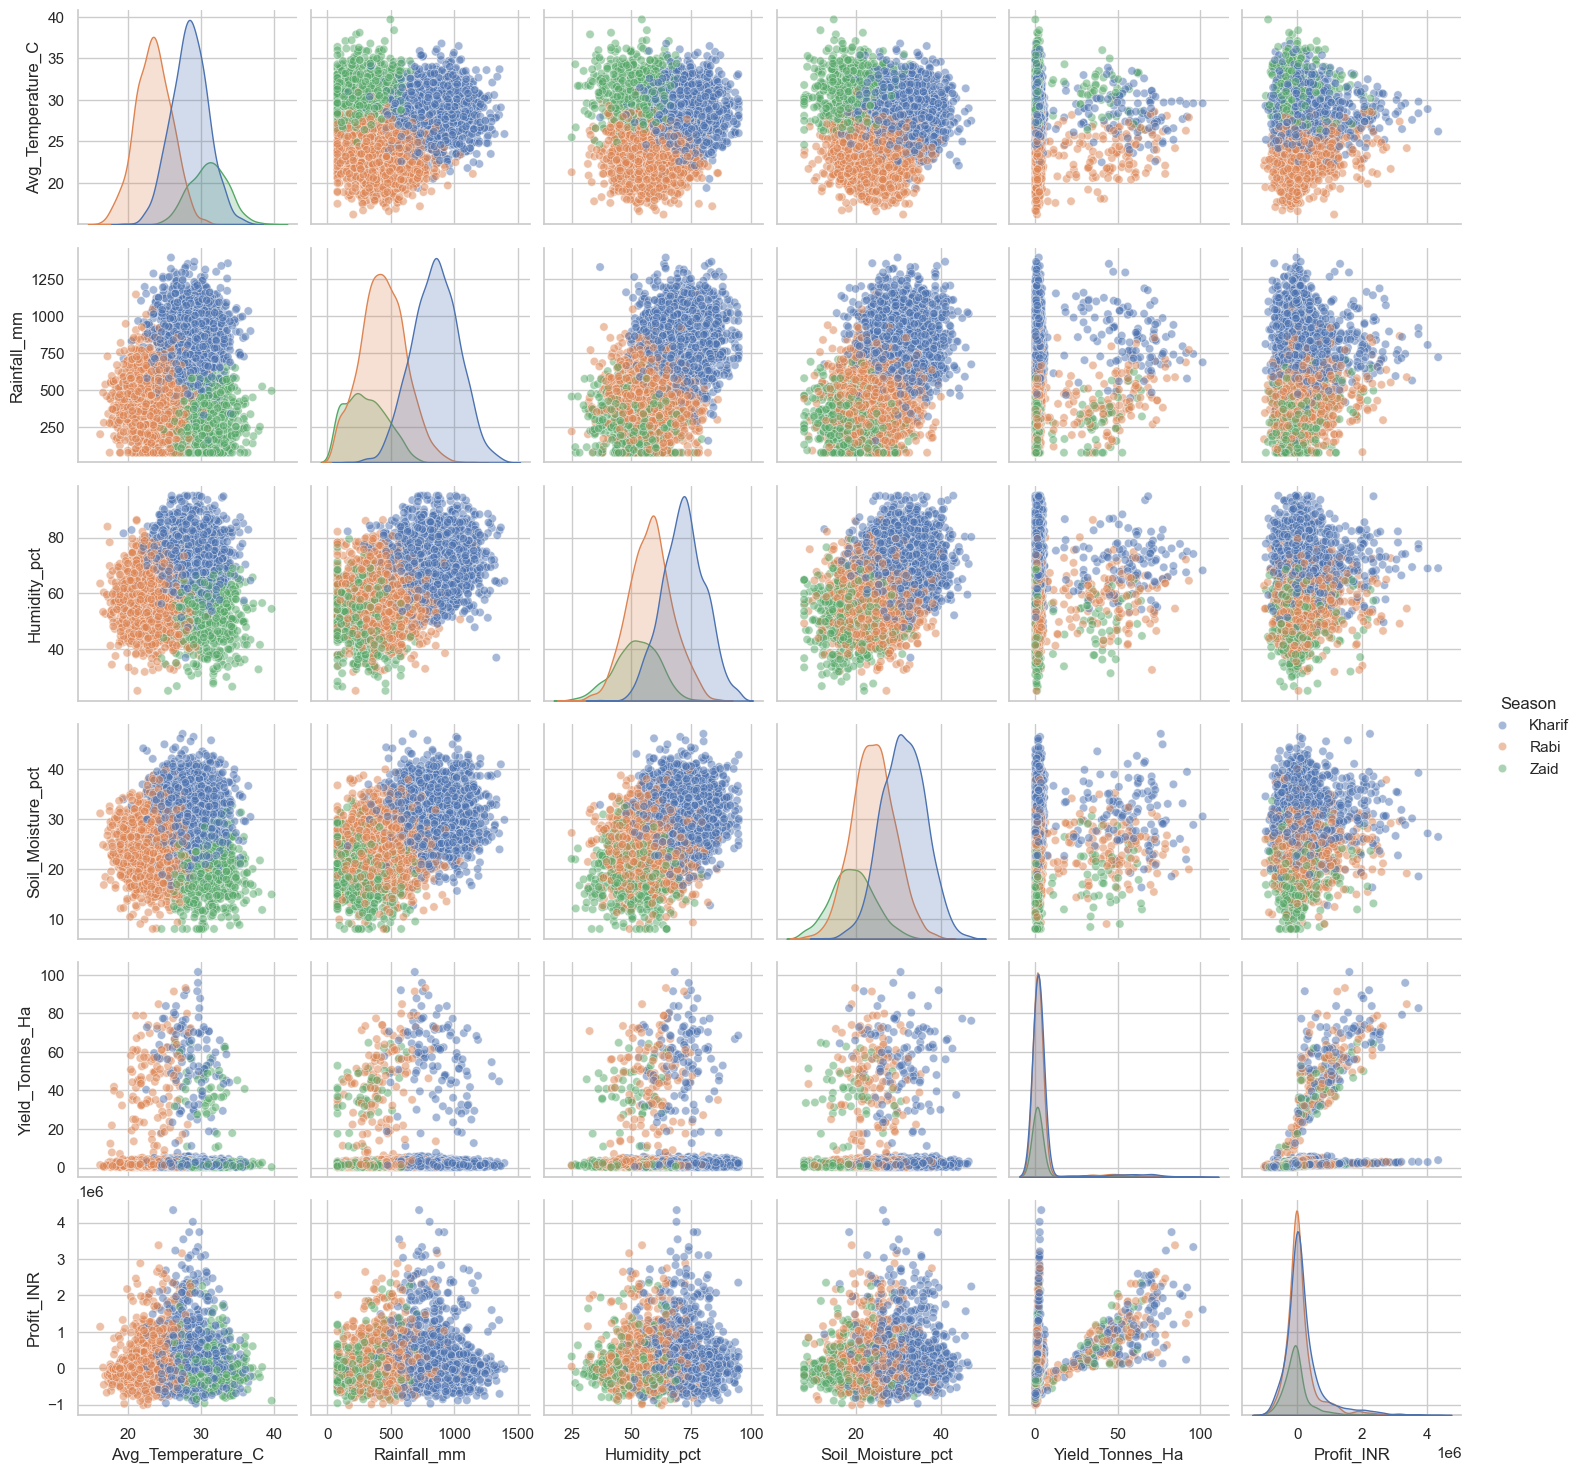

In [85]:
# Pair plot of important environmental and performance variables

selected_columns = [
    "Avg_Temperature_C",
    "Rainfall_mm",
    "Humidity_pct",
    "Soil_Moisture_pct",
    "Yield_Tonnes_Ha",
    "Profit_INR",
    "Season"
]

sns.pairplot(
    df[selected_columns],
    hue="Season",
    plot_kws={"alpha": 0.5}
)

plt.show()

In [86]:
# Create a compact comparison table

season_comparison = (
    df.groupby("Season")
    .agg(
        Average_Yield=("Yield_Tonnes_Ha", "mean"),
        Average_Profit=("Profit_INR", "mean"),
        Average_Water_Used=("Water_Used_m3", "mean"),
        Average_Water_Efficiency=(
            "Water_Efficiency_t_per_1000m3",
            "mean"
        ),
        Average_Rainfall=("Rainfall_mm", "mean"),
        Average_Temperature=("Avg_Temperature_C", "mean"),
        Average_Soil_Moisture=("Soil_Moisture_pct", "mean"),
        Average_Risk=("Disease_Pest_Risk_pct", "mean")
    )
    .round(2)
)

season_comparison

,Average_Yield,Average_Profit,Average_Water_Used,Average_Water_Efficiency,Average_Rainfall,Average_Temperature,Average_Soil_Moisture,Average_Risk
Season,,,,,,,,
Kharif,5.63,"178,914.65","6,102.20",5.89,849.20,28.45,31.15,54.47
Rabi,5.04,"87,689.47","5,846.99",5.19,437.62,23.49,24.07,40.48
Zaid,4.64,"-24,804.82","6,419.89",4.41,304.65,31.04,19.28,38.22


In [87]:
# Identify highest and lowest performing seasons based on average yield

best_yield_season = season_comparison["Average_Yield"].idxmax()
worst_yield_season = season_comparison["Average_Yield"].idxmin()

best_profit_season = season_comparison["Average_Profit"].idxmax()
worst_profit_season = season_comparison["Average_Profit"].idxmin()

print("Highest average yield season:", best_yield_season)
print("Lowest average yield season:", worst_yield_season)

print("\nHighest average profit season:", best_profit_season)
print("Lowest average profit season:", worst_profit_season)

Highest average yield season: Kharif
Lowest average yield season: Zaid

Highest average profit season: Kharif
Lowest average profit season: Zaid


In [88]:
# Find the highest-yielding crop in each season

top_crops_by_season = (
    crop_season_summary
    .sort_values(
        ["Season", "Average_Yield"],
        ascending=[True, False]
    )
    .groupby("Season")
    .head(3)
)

top_crops_by_season.round(2)

,Crop,Season,Average_Yield,Average_Profit,Average_Water_Efficiency,Records
18,Sugarcane,Kharif,53.46,"1,000,790.81",36.00,125
9,Maize,Kharif,2.97,"-39,332.67",6.05,234
15,Rice,Kharif,2.70,"-64,903.40",2.17,314
19,Sugarcane,Rabi,43.29,"731,612.86",27.92,129
10,Maize,Rabi,2.60,"-89,133.40",5.46,233
16,Rice,Rabi,2.32,"-98,427.87",1.84,274
20,Sugarcane,Zaid,38.42,"583,635.80",23.39,51
11,Maize,Zaid,2.29,"-194,049.17",4.75,84
17,Rice,Zaid,1.90,"-227,239.34",1.53,102


In [89]:
# One-way ANOVA: Does average yield differ across seasons?

kharif_yield = df.loc[df["Season"] == "Kharif", "Yield_Tonnes_Ha"]
rabi_yield = df.loc[df["Season"] == "Rabi", "Yield_Tonnes_Ha"]
zaid_yield = df.loc[df["Season"] == "Zaid", "Yield_Tonnes_Ha"]

anova_result = stats.f_oneway(
    kharif_yield,
    rabi_yield,
    zaid_yield
)

print("ANOVA Statistic:", anova_result.statistic)
print("ANOVA p-value:", anova_result.pvalue)

ANOVA Statistic: 1.5438804542488316
ANOVA p-value: 0.21367813841792296


In [90]:
# Interpret ANOVA result

alpha = 0.05

if anova_result.pvalue < alpha:
    print(
        "Result: The difference in mean yield across seasons is "
        "statistically significant at the 5% significance level."
    )
else:
    print(
        "Result: The difference in mean yield across seasons is "
        "not statistically significant at the 5% significance level."
    )

Result: The difference in mean yield across seasons is not statistically significant at the 5% significance level.


In [91]:
# One-way ANOVA: Does average profit differ across seasons?

kharif_profit = df.loc[df["Season"] == "Kharif", "Profit_INR"]
rabi_profit = df.loc[df["Season"] == "Rabi", "Profit_INR"]
zaid_profit = df.loc[df["Season"] == "Zaid", "Profit_INR"]

profit_anova = stats.f_oneway(
    kharif_profit,
    rabi_profit,
    zaid_profit
)

print("Profit ANOVA Statistic:", profit_anova.statistic)
print("Profit ANOVA p-value:", profit_anova.pvalue)

Profit ANOVA Statistic: 34.29175033935196
Profit ANOVA p-value: 1.7124156677360182e-15


In [92]:
# Useful numerical values for final interpretation

print("----- DATASET -----")
print("Rows:", len(df))
print("Columns:", df.shape[1])

print("\n----- SEASONS -----")
print(df["Season"].value_counts())

print("\n----- AVERAGE YIELD BY SEASON -----")
print(df.groupby("Season")["Yield_Tonnes_Ha"].mean().round(2))

print("\n----- AVERAGE PROFIT BY SEASON -----")
print(df.groupby("Season")["Profit_INR"].mean().round(2))

print("\n----- AVERAGE WATER USE BY SEASON -----")
print(df.groupby("Season")["Water_Used_m3"].mean().round(2))

print("\n----- AVERAGE RAINFALL BY SEASON -----")
print(df.groupby("Season")["Rainfall_mm"].mean().round(2))

print("\n----- AVERAGE RISK BY SEASON -----")
print(df.groupby("Season")["Disease_Pest_Risk_pct"].mean().round(2))

print("\n----- AVERAGE YIELD BY IRRIGATION METHOD -----")
print(df.groupby("Irrigation_Method")["Yield_Tonnes_Ha"].mean().round(2))

print("\n----- AVERAGE WATER EFFICIENCY BY IRRIGATION METHOD -----")
print(
    df.groupby("Irrigation_Method")
    ["Water_Efficiency_t_per_1000m3"]
    .mean()
    .round(2)
)

print("\n----- AVERAGE YIELD BY STATE -----")
print(
    df.groupby("State")["Yield_Tonnes_Ha"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
)

----- DATASET -----
Rows: 4000
Columns: 28

----- SEASONS -----
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

----- AVERAGE YIELD BY SEASON -----
Season
Kharif   5.63
Rabi     5.04
Zaid     4.64
Name: Yield_Tonnes_Ha, dtype: float64

----- AVERAGE PROFIT BY SEASON -----
Season
Kharif   178,914.65
Rabi      87,689.47
Zaid     -24,804.82
Name: Profit_INR, dtype: float64

----- AVERAGE WATER USE BY SEASON -----
Season
Kharif   6,102.20
Rabi     5,846.99
Zaid     6,419.89
Name: Water_Used_m3, dtype: float64

----- AVERAGE RAINFALL BY SEASON -----
Season
Kharif   849.20
Rabi     437.62
Zaid     304.65
Name: Rainfall_mm, dtype: float64

----- AVERAGE RISK BY SEASON -----
Season
Kharif   54.47
Rabi     40.48
Zaid     38.22
Name: Disease_Pest_Risk_pct, dtype: float64

----- AVERAGE YIELD BY IRRIGATION METHOD -----
Irrigation_Method
Drip        6.58
Flood       4.86
Rainfed     4.60
Sprinkler   5.16
Name: Yield_Tonnes_Ha, dtype: float64

----- AVERAGE WATER EFFI

## 9. Key Insights

### Insight 1 – Seasonal Yield Variation
**Observation:** Average agricultural yield varies across Kharif, Rabi and Zaid seasons.

**Evidence:** The seasonal yield comparison shows different average yield values for the three seasons.

**Interpretation:** Seasonal conditions are associated with differences in agricultural yield.

**Limitation:** The analysis shows association and does not prove that season alone causes the yield difference.

---

### Insight 2 – Seasonal Profit Variation
**Observation:** Average farm profit differs across seasons.

**Evidence:** The seasonal economic comparison shows differences in average profit.

**Interpretation:** Seasonal conditions and the crop mix may be associated with different economic outcomes.

**Limitation:** Profit also depends on cost, market price, production and crop composition.

---

### Insight 3 – Seasonal Water Usage
**Observation:** Water usage is not the same across all seasons.

**Evidence:** The seasonal water-use comparison shows differences in average water consumption.

**Interpretation:** Water requirements and agricultural resource usage vary across seasons.

**Limitation:** Water usage is also influenced by crop type and irrigation method.

---

### Insight 4 – Seasonal Environmental Differences
**Observation:** Rainfall and other environmental conditions differ between seasons.

**Evidence:** Seasonal environmental summaries and visualizations show variations in rainfall, temperature and soil moisture.

**Interpretation:** Agricultural activities take place under different environmental conditions during different seasons.

**Limitation:** The dataset does not prove a direct causal relationship between one environmental variable and yield.

---

### Insight 5 – Crop Performance is Different
**Observation:** Different crops show different yield and profit levels within the same season.

**Evidence:** The crop-by-season analysis shows substantial variation among crops.

**Interpretation:** Crop selection is an important dimension when comparing agricultural performance.

**Limitation:** Differences may also reflect crop-specific economics, resource requirements and farm conditions.

---

### Insight 6 – Irrigation Methods Differ in Performance
**Observation:** Average yield and water usage vary among irrigation methods.

**Evidence:** The irrigation comparison shows differences in yield and water efficiency across methods.

**Interpretation:** Irrigation method is an important factor for comparing resource use and agricultural performance.

**Limitation:** This is observational analysis and should not be interpreted as a causal experiment.

---

### Insight 7 – Geographic Differences
**Observation:** Agricultural performance varies across states.

**Evidence:** State-level comparisons show different average yield and profit levels.

**Interpretation:** Geographic conditions and farming patterns may be associated with different performance outcomes.

**Limitation:** State-level averages combine multiple crops and farm conditions.

---

### Insight 8 – Yield and Profit are Related
**Observation:** Yield and profit show a measurable relationship in the correlation and scatterplot analysis.

**Evidence:** The correlation matrix and yield-versus-profit scatterplot indicate that higher yield is generally associated with higher profit.

**Interpretation:** Production performance is an important component of economic performance.

**Limitation:** Profit also depends on market price, total cost, production and other factors.

## Additional Data-Specific Observations

The dataset contains 4,000 farm-level records covering three agricultural
seasons: Kharif, Rabi and Zaid.

The dataset contains 28 variables covering:
- Farm and geographic information
- Crops and seasons
- Environmental conditions
- Soil characteristics
- Fertilizer and pesticide usage
- Irrigation
- Yield and production
- Cost, revenue and profit
- Water usage and water efficiency
- Disease and pest risk

Missing-value analysis identified missing observations in selected numerical
variables. These were handled using median imputation, while duplicate records
were checked before analysis.

The results show that agricultural performance is multidimensional. Yield,
profit, resource usage, environmental conditions, crop type and irrigation
method should therefore be considered together rather than using a single
measure of performance.

## 10. Recommendations

1. Seasonal planning should consider differences in yield, rainfall, water
   usage and economic performance across Kharif, Rabi and Zaid.

2. Crop selection should be evaluated separately for each season because crop
   performance varies across seasonal conditions.

3. Irrigation methods should be compared using both yield and water efficiency,
   rather than yield alone.

4. Farmers and planners should consider geographic differences when evaluating
   agricultural performance across states.

5. Environmental conditions such as rainfall and soil moisture should be
   monitored as part of seasonal agricultural planning.

6. Economic decisions should consider revenue, total cost and profit together
   instead of focusing only on production or yield.

7. Crops or regions showing unusual performance should be investigated further
   instead of automatically treating extreme observations as errors.

8. Future analysis should use larger time-based datasets to verify whether the
   observed seasonal patterns remain consistent over multiple years.

## 11. Limitations

1. The analysis is based only on the variables available in the provided
   dataset.

2. The dataset represents observations across farms, but the analysis does not
   establish causal relationships.

3. Seasonal comparisons may be influenced by differences in crop composition.

4. Missing numerical observations were handled using median imputation, which
   may reduce some natural variation.

5. Outliers were investigated but were not automatically removed because an
   extreme observation may represent a genuine agricultural condition.

6. The analysis is descriptive and statistical rather than a predictive
   forecasting model.

7. Results should not be generalized beyond the population represented by the
   available dataset without additional validation.

## 12. Conclusion

The Seasonal Agriculture Performance Analysis provides a structured view of
agricultural performance across different seasons, crops, locations,
environmental conditions, resource-use patterns and economic outcomes.

The analysis shows that agricultural performance is multidimensional. Seasonal
comparisons reveal differences in yield, profitability, rainfall, water usage
and risk. Crop-level and irrigation-level comparisons further demonstrate that
performance varies across agricultural practices and categories.

Correlation analysis helps identify relationships among environmental,
production and economic variables, while statistical analysis provides
additional evidence for evaluating seasonal differences.

Overall, the findings can support evidence-based seasonal agricultural planning.
However, the results should be interpreted as relationships observed in the
available data rather than proof of causation.

Further work using multi-year data, predictive models and more detailed
farm-level information could provide stronger decision-support capabilities.

## 13. Project Checklist

- [x] Dataset loaded successfully
- [x] Dataset shape and structure examined
- [x] Top and random records examined
- [x] Data types examined
- [x] Missing values identified
- [x] Missing values handled
- [x] Duplicate records checked
- [x] Numerical descriptive statistics performed
- [x] Categorical analysis performed
- [x] Outliers investigated
- [x] Univariate analysis completed
- [x] Bivariate analysis completed
- [x] Multivariate analysis completed
- [x] Correlation analysis completed
- [x] Seasonal comparison completed
- [x] Crop-season analysis completed
- [x] Irrigation analysis completed
- [x] State-level analysis completed
- [x] Environmental analysis completed
- [x] Water-efficiency analysis completed
- [x] Economic analysis completed
- [x] Disease/pest risk analysis completed
- [x] Statistical testing completed
- [x] At least 3 student-designed analyses completed
- [x] At least 8 key insights documented
- [x] Recommendations provided
- [x] Limitations discussed
- [x] Conclusion provided